## 패키지 설치

In [1]:
# %conda install imbalanced-learn
# %conda install statsmodels

In [2]:
# ─────────────────────────────────────────────
# numpy, PyTorch, matplotlib 설치
# ─────────────────────────────────────────────
import subprocess, sys
packages = ["numpy", "torch", "matplotlib"]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"],
        stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT
    )
import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
import platform
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix)
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

print(f"✅ numpy     {np.__version__}")
print(f"✅ pandas     {pd.__version__}")
print(f"✅ torch     {torch.__version__}")
print(f"✅ matplotlib {matplotlib.__version__}")

✅ numpy     2.2.5
✅ pandas     2.3.3
✅ torch     2.11.0
✅ matplotlib 3.10.8


# 데이터 로드 및 확인
## E-Commerce Customer Churn

| 항목 | 내용 |
|---|---|
| 데이터 크기 | 5,630행 × 20컬럼 |
| **타겟 변수** | `Churn` (0 = 유지, 1 = 이탈) |
| 이탈 비율 | 약 16.8% (클래스 불균형 주의) |
| 주요 피처 | Tenure, SatisfactionScore, Complain, DaySinceLastOrder, CashbackAmount 등 |

In [3]:
# 데이터 기본 정보 확인
df = pd.read_csv("data/E Commerce Dataset.csv")
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [4]:
# 컬럼별 항목(count, mean, std, min, 25%, 50%, 75%, max)
df.describe().T.style.format("{:.2f}").set_properties(**{'text-align': 'left'})\
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
print(len(df))

5630


## 범주형/수치형 데이터 확인

|  | select_dtypes |
| --- | ---|
|범주형 |  object, category |
|수치형 |  int64, float64 |

- 추가적으로 `CityTier`는 수치형(1~3)으로 나타나지만, 의미가 순서나 크기를 나타내지 않기에 범주형으로 처리
- 숫자의 크기가 중요한 것이 아닌, 그룹이 중요한 것이기에 추후에 `One-Hot Encoding`할 예정

In [5]:
# 범주형, 수치형 데이터 확인

# 데이터 타입 기준으로 1차 분류
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 숫자로 되어 있으나 '범주형' 취급하고 싶은 컬럼 정의
to_category = ['CityTier']

# 수치형 리스트에서 제거하고 범주형 리스트에 추가
num_cols = [col for col in num_cols if col not in to_category]
cat_cols = list(set(cat_cols + to_category))                        # 중복방지위해 set 설정   

# 수치형 요약
num_summary = pd.DataFrame({
        "컬럼명": num_cols,
})
print(f"🔢 수치형 컬럼 (Numerical) — 총 {len(num_cols)}개")
display(num_summary.style.set_properties(**{'text-align': 'left'})
                  .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))


# 범주형 요약
cat_summary = pd.DataFrame({
    "컬럼명": cat_cols,
    "고유값 개수": [df[col].nunique() for col in cat_cols],
    "고유값 목록": [df[col].unique().tolist() for col in cat_cols] 
})
print(f"📂 범주형 컬럼 (Categorical) — 총 {len(cat_cols)}개")
display(cat_summary.style.set_properties(**{'text-align': 'left'})
                  .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

🔢 수치형 컬럼 (Numerical) — 총 14개


,컬럼명
0,CustomerID
1,Churn
2,Tenure
3,WarehouseToHome
4,HourSpendOnApp
5,NumberOfDeviceRegistered
6,SatisfactionScore
7,NumberOfAddress
8,Complain
9,OrderAmountHikeFromlastYear


📂 범주형 컬럼 (Categorical) — 총 6개


,컬럼명,고유값 개수,고유값 목록
0,PreferredLoginDevice,3,"['Mobile Phone', 'Phone', 'Computer']"
1,Gender,2,"['Female', 'Male']"
2,MaritalStatus,3,"['Single', 'Divorced', 'Married']"
3,CityTier,3,"[3, 1, 2]"
4,PreferredPaymentMode,7,"['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD', 'Credit Card']"
5,PreferedOrderCat,6,"['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']"


# 범주형 데이터 정제 및 통합

In [6]:
# 범주형 데이터 정제 및 통합

print("정제 전 고유값:")
print(f"  PreferredLoginDevice : {sorted(df['PreferredLoginDevice'].unique())}")
print(f"  PreferedOrderCat     : {sorted(df['PreferedOrderCat'].unique())}")
print(f"  PreferredPaymentMode : {sorted(df['PreferredPaymentMode'].unique())}")

# ── PreferredLoginDevice: Mobile Phone → Phone 으로 통일 ─────────────
df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Mobile Phone": "Phone"})

# ── PreferedOrderCat: Mobile Phone → Mobile 으로 통일 ────────────────
df["PreferedOrderCat"] = df["PreferedOrderCat"].replace({"Mobile Phone": "Mobile"})

# ── PreferredPaymentMode: 중복 표기 통일 ─────────────────────────────
#    COD + Cash on Delivery → "COD"         (약어로 통일)
#    CC  + Credit Card      → "Credit Card" (정식 명칭으로 통일)
#    최종 5종: COD / Credit Card / Debit Card / E wallet / UPI
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
    "Cash on Delivery": "COD",
    "CC"              : "Credit Card",
})

print("\n정제 후 고유값:")
print(f"  PreferredLoginDevice : {sorted(df['PreferredLoginDevice'].unique())}")
print(f"  PreferedOrderCat     : {sorted(df['PreferedOrderCat'].unique())}")
print(f"  PreferredPaymentMode : {sorted(df['PreferredPaymentMode'].unique())}")

정제 전 고유값:
  PreferredLoginDevice : ['Computer', 'Mobile Phone', 'Phone']
  PreferedOrderCat     : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others']
  PreferredPaymentMode : ['CC', 'COD', 'Cash on Delivery', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']

정제 후 고유값:
  PreferredLoginDevice : ['Computer', 'Phone']
  PreferedOrderCat     : ['Fashion', 'Grocery', 'Laptop & Accessory', 'Mobile', 'Others']
  PreferredPaymentMode : ['COD', 'Credit Card', 'Debit Card', 'E wallet', 'UPI']


# 데이터 전처리
## 1. 중복 데이터 확인

In [7]:
# 중복 데이터 확인
dup_count = df.duplicated().sum()
print(f"전체 중복 데이터 수: {dup_count}개")

전체 중복 데이터 수: 0개


## 2. 결측치

### 1. 결측치 확인

In [8]:
missing_sr = df.isnull().sum()
missing_sr = missing_sr[missing_sr > 0]  # 결측치 있는 컬럼만
missing_cols = missing_sr.index.tolist()  # 이후 모든 셀에서 이걸 재사용

In [9]:
# ─────────────────────────────────────────────
# 1. 결측치 확인
# ─────────────────────────────────────────────
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "결측치 수": missing_counts,
    "결측치 비율(%)": missing_pct
})
missing_df = missing_df[missing_df["결측치 수"] > 0].sort_values("결측치 수", ascending=False)

if missing_df.empty:
    print("✅ 모든 컬럼의 결측치가 처리되어 깨끗합니다!")
else:
    # 나중에 재사용할 결측치 컬럼 리스트 저장
    missing_cols = missing_df.index.tolist()
    
    print(f"⚠️ 결측치가 남아있는 컬럼: {len(missing_df)}개")
    print("-" * 40)
    print(missing_df.to_string())

⚠️ 결측치가 남아있는 컬럼: 7개
----------------------------------------
                             결측치 수  결측치 비율(%)
DaySinceLastOrder              307       5.45
OrderAmountHikeFromlastYear    265       4.71
Tenure                         264       4.69
OrderCount                     258       4.58
CouponUsed                     256       4.55
HourSpendOnApp                 255       4.53
WarehouseToHome                251       4.46


### 2. 결측치 방법 비교 (중간값 vs 평균)

💡 결측치 방법 판단 기준: 
   - 분포가 대칭(정규분포)에 가깝다면 → 평균값(mean)이 적합
   - 분포가 한쪽으로 치우쳐 있거나(왜도가 큰 경우) 이상치가 있다면 → 중간값(median)이 안전

,결측치 수,중간값,평균값,결측치 비율(%),왜도(skewness),권장
DaySinceLastOrder,307,3.000000,4.540000,5.450000,1.190000,중간값 권장 (|왜도|>0.5)
OrderAmountHikeFromlastYear,265,15.000000,15.710000,4.710000,0.790000,중간값 권장 (|왜도|>0.5)
Tenure,264,9.000000,10.190000,4.690000,0.740000,중간값 권장 (|왜도|>0.5)
OrderCount,258,2.000000,3.010000,4.580000,2.200000,중간값 권장 (|왜도|>0.5)
CouponUsed,256,1.000000,1.750000,4.550000,2.550000,중간값 권장 (|왜도|>0.5)
HourSpendOnApp,255,3.000000,2.930000,4.530000,-0.030000,평균값 권장
WarehouseToHome,251,14.000000,15.640000,4.460000,1.620000,중간값 권장 (|왜도|>0.5)


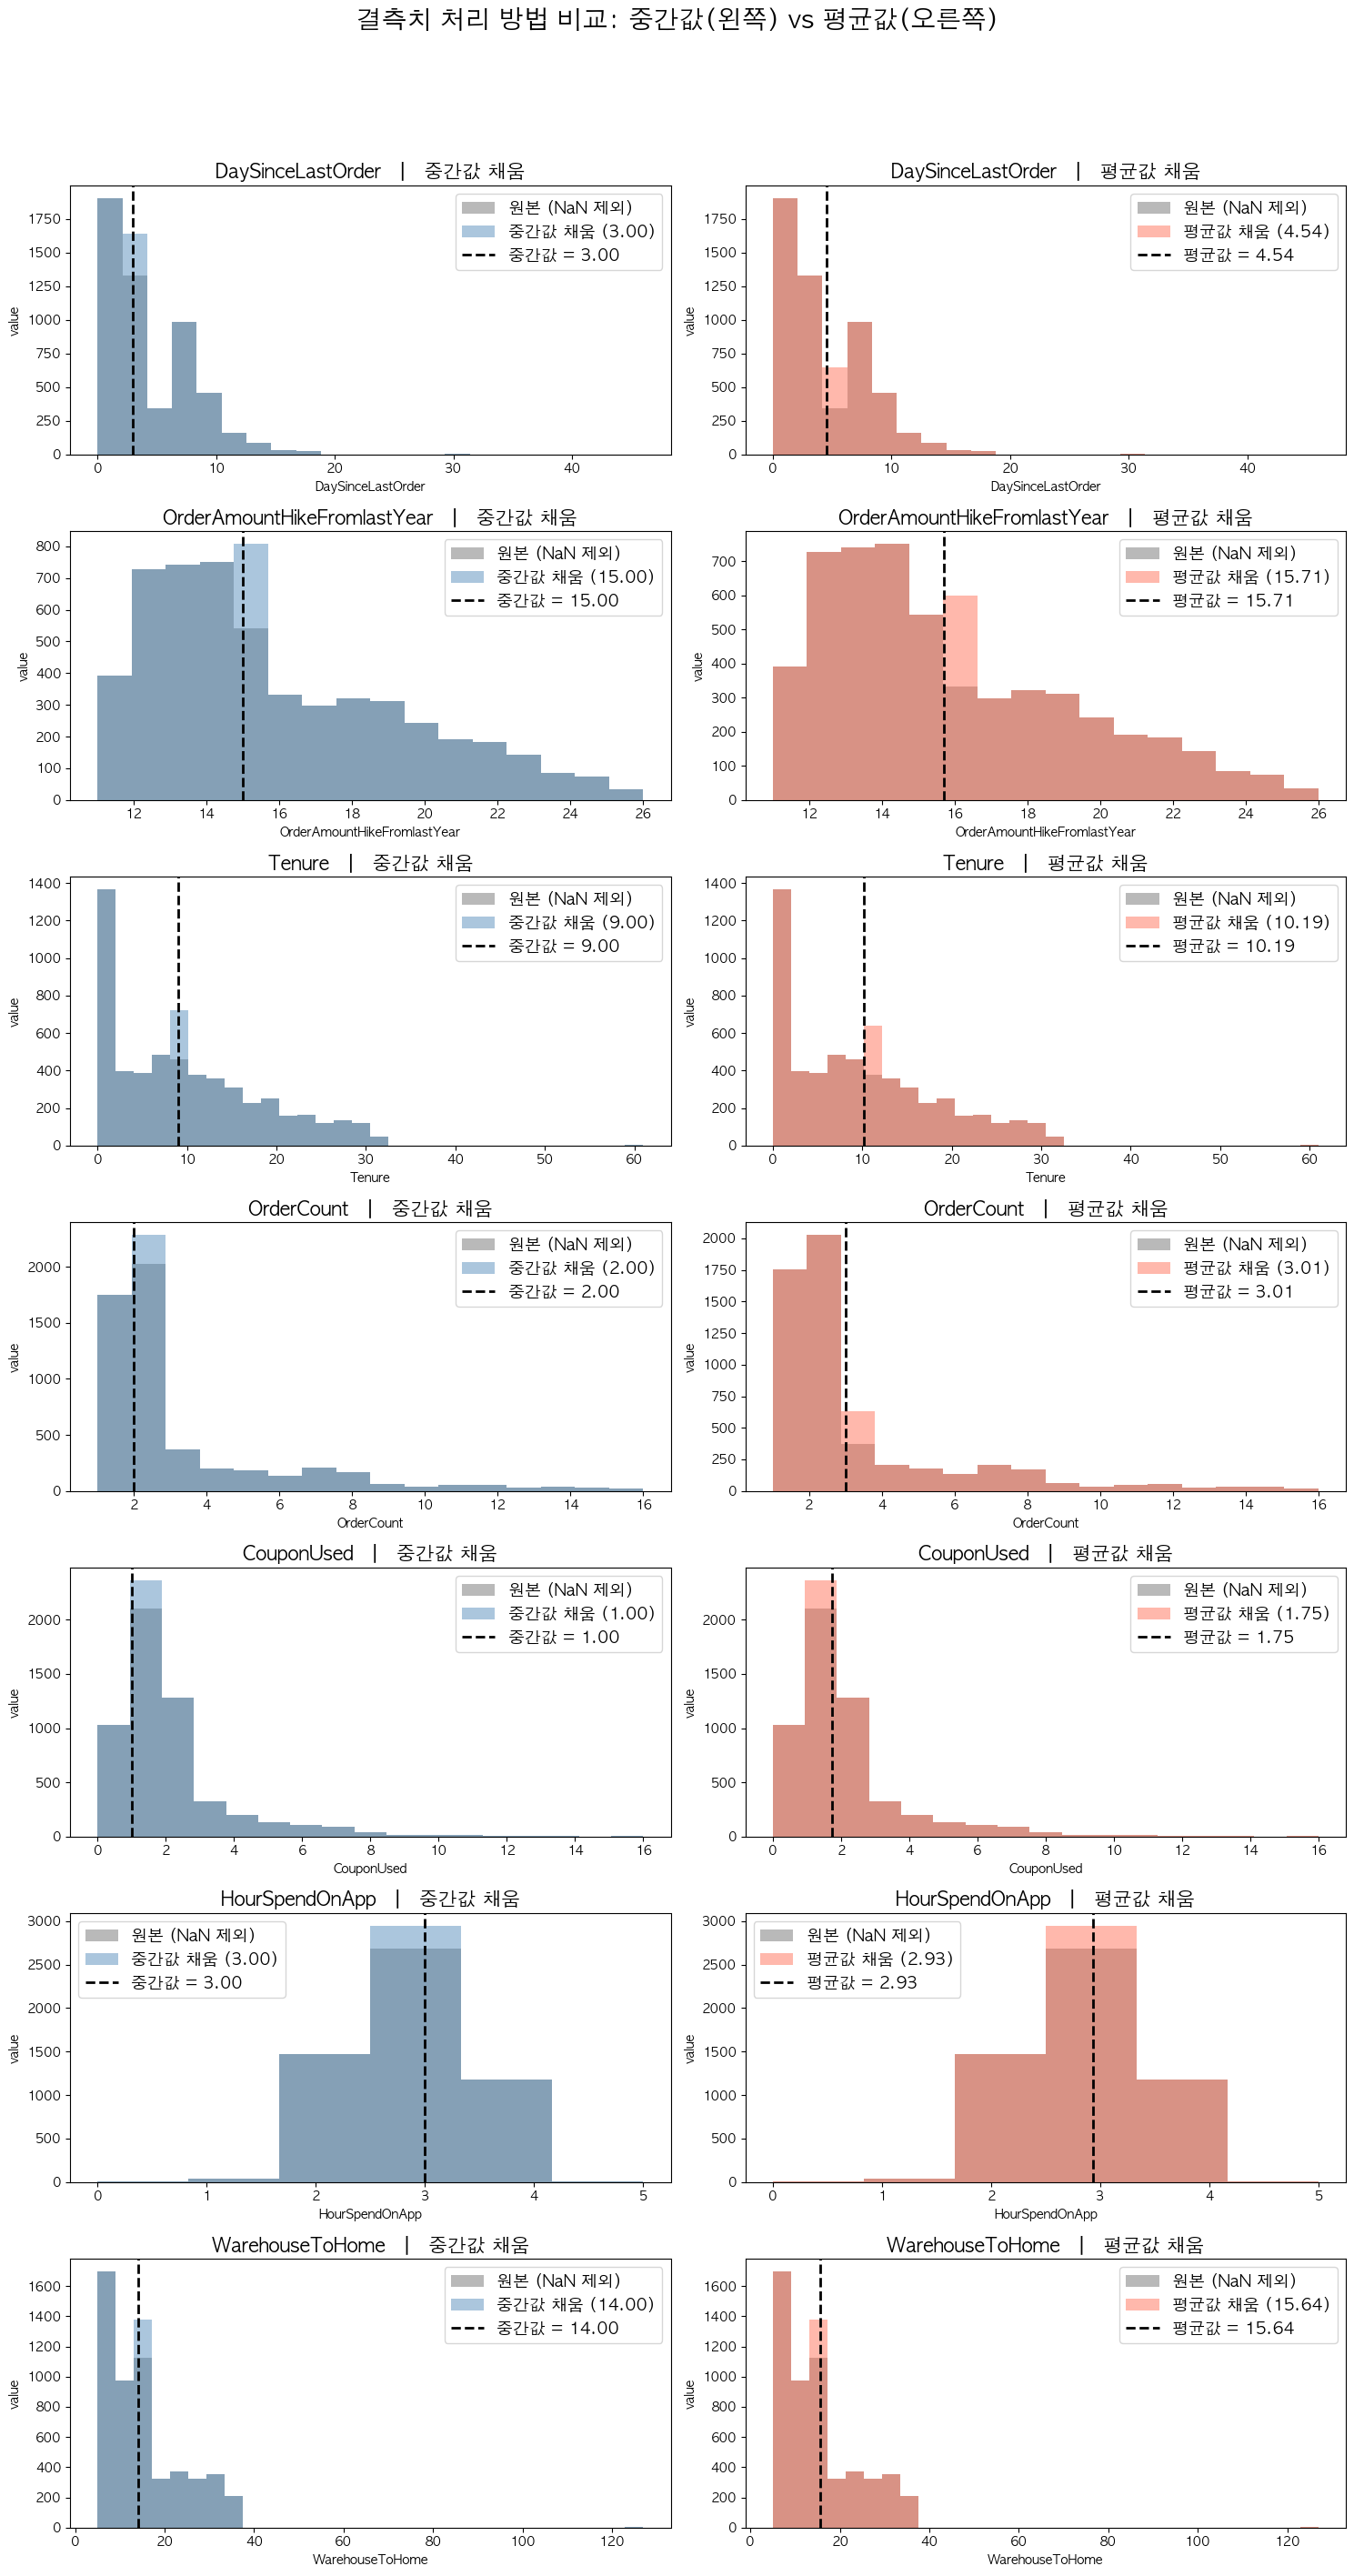

In [10]:
# ─────────────────────────────────────────────
# 2. 결측치 방법 비교 (중간값 vs 평균)
# ─────────────────────────────────────────────

# 결측치가 있는 컬럼 목록
missing_cols = [
    "DaySinceLastOrder",
    "OrderAmountHikeFromlastYear",
    "Tenure",
    "OrderCount",
    "CouponUsed",
    "HourSpendOnApp",
    "WarehouseToHome"
]
n = len(missing_cols)
total_rows = len(df)                   # 전체 행 수 계산

summary = pd.DataFrame({
    "결측치 수": df[missing_cols].isnull().sum(),
    "중간값": df[missing_cols].median().round(2),
    "평균값": df[missing_cols].mean().round(2),
    "결측치 비율(%)": (df[missing_cols].isnull().sum() / total_rows * 100).round(2),
    "왜도(skewness)": df[missing_cols].skew().round(2)
})
summary["권장"] = summary["왜도(skewness)"].apply(
    lambda s: "중간값 권장 (|왜도|>0.5)" if abs(s) > 0.5 else "평균값 권장"
)

# 많이 치우쳐진 CouponUsed, OrderCount는 결측치 처리 후, 로그 변환 예정

display(summary.style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

fig, axes = plt.subplots(n, 2, figsize=(15, 4 * n))
fig.suptitle("결측치 처리 방법 비교: 중간값(왼쪽) vs 평균값(오른쪽)", fontsize=20, fontweight="bold", y=1.01)

for i, col in enumerate(missing_cols):
    original   = df[col].dropna()
    median_val = df[col].median()
    mean_val   = df[col].mean()

    filled_median = df[col].fillna(median_val)
    filled_mean   = df[col].fillna(mean_val)

    bins = min(30, int(df[col].nunique()))
    bin_edges_m = np.histogram_bin_edges(filled_median, bins=bins)
    bin_edges_n = np.histogram_bin_edges(filled_mean,   bins=bins)

    # ── 왼쪽: 중간값 채움 ──
    ax_l = axes[i, 0]
    ax_l.hist(original,      bins=bin_edges_m, alpha=0.55, color="gray",     label="원본 (NaN 제외)")
    ax_l.hist(filled_median, bins=bin_edges_m, alpha=0.45, color="steelblue", label=f"중간값 채움 ({median_val:.2f})")
    ax_l.axvline(median_val, color="black", linestyle="--", linewidth=2, label=f"중간값 = {median_val:.2f}")
    ax_l.set_title(f"{col}  ┃  중간값 채움", fontsize=15)
    ax_l.set_xlabel(col)
    ax_l.set_ylabel("value")
    ax_l.legend(fontsize=13)

    # ── 오른쪽: 평균값 채움 ──
    ax_r = axes[i, 1]
    ax_r.hist(original,    bins=bin_edges_n, alpha=0.55, color="gray",   label="원본 (NaN 제외)")
    ax_r.hist(filled_mean, bins=bin_edges_n, alpha=0.45, color="tomato", label=f"평균값 채움 ({mean_val:.2f})")
    ax_r.axvline(mean_val, color="black", linestyle="--", linewidth=2, label=f"평균값 = {mean_val:.2f}")
    ax_r.set_title(f"{col}  ┃  평균값 채움", fontsize=15)
    ax_r.set_xlabel(col)
    ax_r.set_ylabel("value")
    ax_r.legend(fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### 3. 결측치 처리

- 결측치 비율이 10% 미만으로 매우 낮기 때문에, 데이터 손실 최소화를 위해 적절한 값(중간값/평균값)으로 채움
- 데이터의 분포가 한쪽으로 치우쳐 있는 경우(왜도가 큰 경우), <br> 평균값은 극단적인 값(이상치)에 민감하게 반응하여 데이터의 대표성을 잃기 때문에, 더 안정적인 중간값을 선택하여 데이터의 왜곡 방지

|     | 결측치 수/전체(개) | 결측치 비율(%) | 왜도(skewness) | 권장  |
| --- | --- | --- | --- | --- |
| DaySinceLastOrder | 307 / 5,630 | 5.450000 | 1.190000 | 중간값 권장 (\|왜도\|>0.5) |
| OrderAmountHikeFromlastYear | 265/5,630 | 4.710000 | 0.790000 | 중간값 권장 (\|왜도\|>0.5) |
| Tenure | 264 / 5,630 | 4.690000 | 0.740000 | 중간값 권장 (\|왜도\|>0.5) |
| OrderCount | 258 / 5,630 | 4.580000 | 2.200000 | 중간값 권장 (\|왜도\|>0.5) |
| CouponUsed | 256 / 5,630 | 4.550000 | 2.550000 | 중간값 권장 (\|왜도\|>0.5) |
| <mark style='background-color: LemonChiffon'>HourSpendOnApp</mark> | <mark style='background-color: LemonChiffon'>255 / 5,630</mark> | <mark style='background-color: LemonChiffon'>4.530000</mark> | <mark style='background-color: LemonChiffon'>\-0.030000 </mark>|<mark style='background-color: LemonChiffon'> 평균값 권장</mark> |
| WarehouseToHome | 251 / 5,630 | 4.460000 | 1.620000 | 중간값 권장 (\|왜도\|>0.5) |
- `HourSpendOnApp` : 왜도가 -0.03으로 0에 매우 가까움 = 데이터 정규분포를 따르므로, 가장 일반적인 통계량인 평균값을 사용함.
- 그 외 항목들 : 왜도가 0.5를 초과하므로, 데이터의 중심을 더 잘 나타내는 중간값을 사용함.


In [11]:
# ─────────────────────────────────────────────
# 3. 결측치 채우기
# ─────────────────────────────────────────────
# 결측치 채우기 전 원본 보관
df_before = df.copy()
print('원본 저장 완료 (df_before)')

fill_method = "median"   

for col in missing_cols:
    if col == "HourSpendOnApp":
        # HourSpendOnApp은 설정과 상관없이 무조건 평균값 적용
        df[col] = df[col].fillna(df[col].mean())
        print(f"- {col:30s}: 평균값(mean)적용")
    else:
        # 나머지 컬럼은 기본 설정된 방법(median) 적용
        if fill_method == "median":
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mean())
        print(f"- {col:30s}: 중간값(median)적용")

remaining = df[missing_cols].isnull().sum().sum()
print(f"\n✅ 결측치 채움 완료")
print(f"   남은 결측치: {remaining}개")

원본 저장 완료 (df_before)
- DaySinceLastOrder             : 중간값(median)적용
- OrderAmountHikeFromlastYear   : 중간값(median)적용
- Tenure                        : 중간값(median)적용
- OrderCount                    : 중간값(median)적용
- CouponUsed                    : 중간값(median)적용
- HourSpendOnApp                : 평균값(mean)적용
- WarehouseToHome               : 중간값(median)적용

✅ 결측치 채움 완료
   남은 결측치: 0개


In [12]:
# 결측치가 있던 행들 5개 추출하여 확인
null_mask = df_before[missing_cols].isnull().any(axis=1)
null_idx  = df_before[null_mask].index[:5]

print('=== 🔈처리 전 (NaN 있는 상태) ===')
display(df_before.loc[null_idx].style
        .format(subset=df_before
        .select_dtypes(include='number').columns, formatter="{:.2f}")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

print('\n=== 🔊 처리 후 (채워진 상태) ===')
num_cols = df.select_dtypes(include='number').columns
display(df.loc[null_idx].style
        .format(subset=[col for col in num_cols if col in df.columns], formatter="{:.2f}")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

=== 🔈처리 전 (NaN 있는 상태) ===


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1,50002.00,1.00,nan,Phone,1.00,8.00,UPI,Male,3.00,4.00,Mobile,3.00,Single,7.00,1.00,15.00,0.00,1.00,0.00,121.00
2,50003.00,1.00,nan,Phone,1.00,30.00,Debit Card,Male,2.00,4.00,Mobile,3.00,Single,6.00,1.00,14.00,0.00,1.00,3.00,120.00
4,50005.00,1.00,0.00,Phone,1.00,12.00,Credit Card,Male,nan,3.00,Mobile,5.00,Single,3.00,0.00,11.00,1.00,1.00,3.00,130.00
6,50007.00,1.00,nan,Phone,3.00,11.00,COD,Male,2.00,3.00,Laptop & Accessory,2.00,Divorced,4.00,0.00,14.00,0.00,1.00,0.00,121.00
7,50008.00,1.00,nan,Phone,1.00,6.00,Credit Card,Male,3.00,3.00,Mobile,2.00,Divorced,3.00,1.00,16.00,2.00,2.00,0.00,123.00



=== 🔊 처리 후 (채워진 상태) ===


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
1,50002.00,1.00,9.00,Phone,1.00,8.00,UPI,Male,3.00,4.00,Mobile,3.00,Single,7.00,1.00,15.00,0.00,1.00,0.00,121.00
2,50003.00,1.00,9.00,Phone,1.00,30.00,Debit Card,Male,2.00,4.00,Mobile,3.00,Single,6.00,1.00,14.00,0.00,1.00,3.00,120.00
4,50005.00,1.00,0.00,Phone,1.00,12.00,Credit Card,Male,2.93,3.00,Mobile,5.00,Single,3.00,0.00,11.00,1.00,1.00,3.00,130.00
6,50007.00,1.00,9.00,Phone,3.00,11.00,COD,Male,2.00,3.00,Laptop & Accessory,2.00,Divorced,4.00,0.00,14.00,0.00,1.00,0.00,121.00
7,50008.00,1.00,9.00,Phone,1.00,6.00,Credit Card,Male,3.00,3.00,Mobile,2.00,Divorced,3.00,1.00,16.00,2.00,2.00,0.00,123.00


### 4. 결측치 처리 전후 비교

**1. 결측치 처리 요약**

- 왜도 기준으로 결측치 처리
- 중간값(Median) 채우기: 7개 중 6개 변수 (`Tenure`, `OrderCount` 등)
    - 데이터가 한쪽으로 길게 늘어진 모양이라 평균을 쓰면 값이 왜곡됨 → 가장 가운데 위치한 '중간값’ 채움
- 평균값(Mean) 채우기: `HourSpendOnApp` (딱 1개)
    - 그래프 모양이 정규분포에 가깝기에 전체의 평균을 사용해도 데이터의 성격이 변하지 않음


**2\. 그래프 분석 (하늘색 막대(전) vs 주황색 선(후))**

그래프에서 <font style='color: blue'>하늘색(전)</font>과 <font style='color: orange'>주황색(후)</font>이 얼마나 겹치느냐가 핵심

- 분포의 일치성 : 주황색 곡선이 하늘색 막대의 흐름을 거의 그대로 따라감 -> 결측치를 채운 후에도 **데이터 본래의 특징이 아주 잘 유지**됨을 보여줌 
- 특정 지점의 상승 : `OrderCount`나 `DaySinceLastOrder` 특정 구간에서 <font style='color: orange'>주황색(후)</font> 선이 뾰족하게 솟아 있음 -> 수백 개의 빈칸을 하나의 숫자(중간값)로 채웠기에 그 지점의 밀도가 높아진 것


**3\. 통계적 성과 (데이터 품질 확인)**

| 항목 | 분석 결과 |의미|
| --- | --- | --- |
| 결측치 비율 | 약 4.5% ~ 5.5% | 무시하기엔 많고 버리기엔 아까운 수치로 모두 살림 |
| 데이터 보존 | 5,630건 전체 유지 | 결측치 포함 행 미삭제로 학습 데이터 양을 확보 |
| 분포 왜곡 | 최소화 | 왜도에 따른 맞춤형 채우기로 데이터의 '편향'을 막음 |

,처리 전,처리 후,채워진 수
CouponUsed,256,0,256
DaySinceLastOrder,307,0,307
HourSpendOnApp,255,0,255
OrderAmountHikeFromlastYear,265,0,265
OrderCount,258,0,258
Tenure,264,0,264
WarehouseToHome,251,0,251


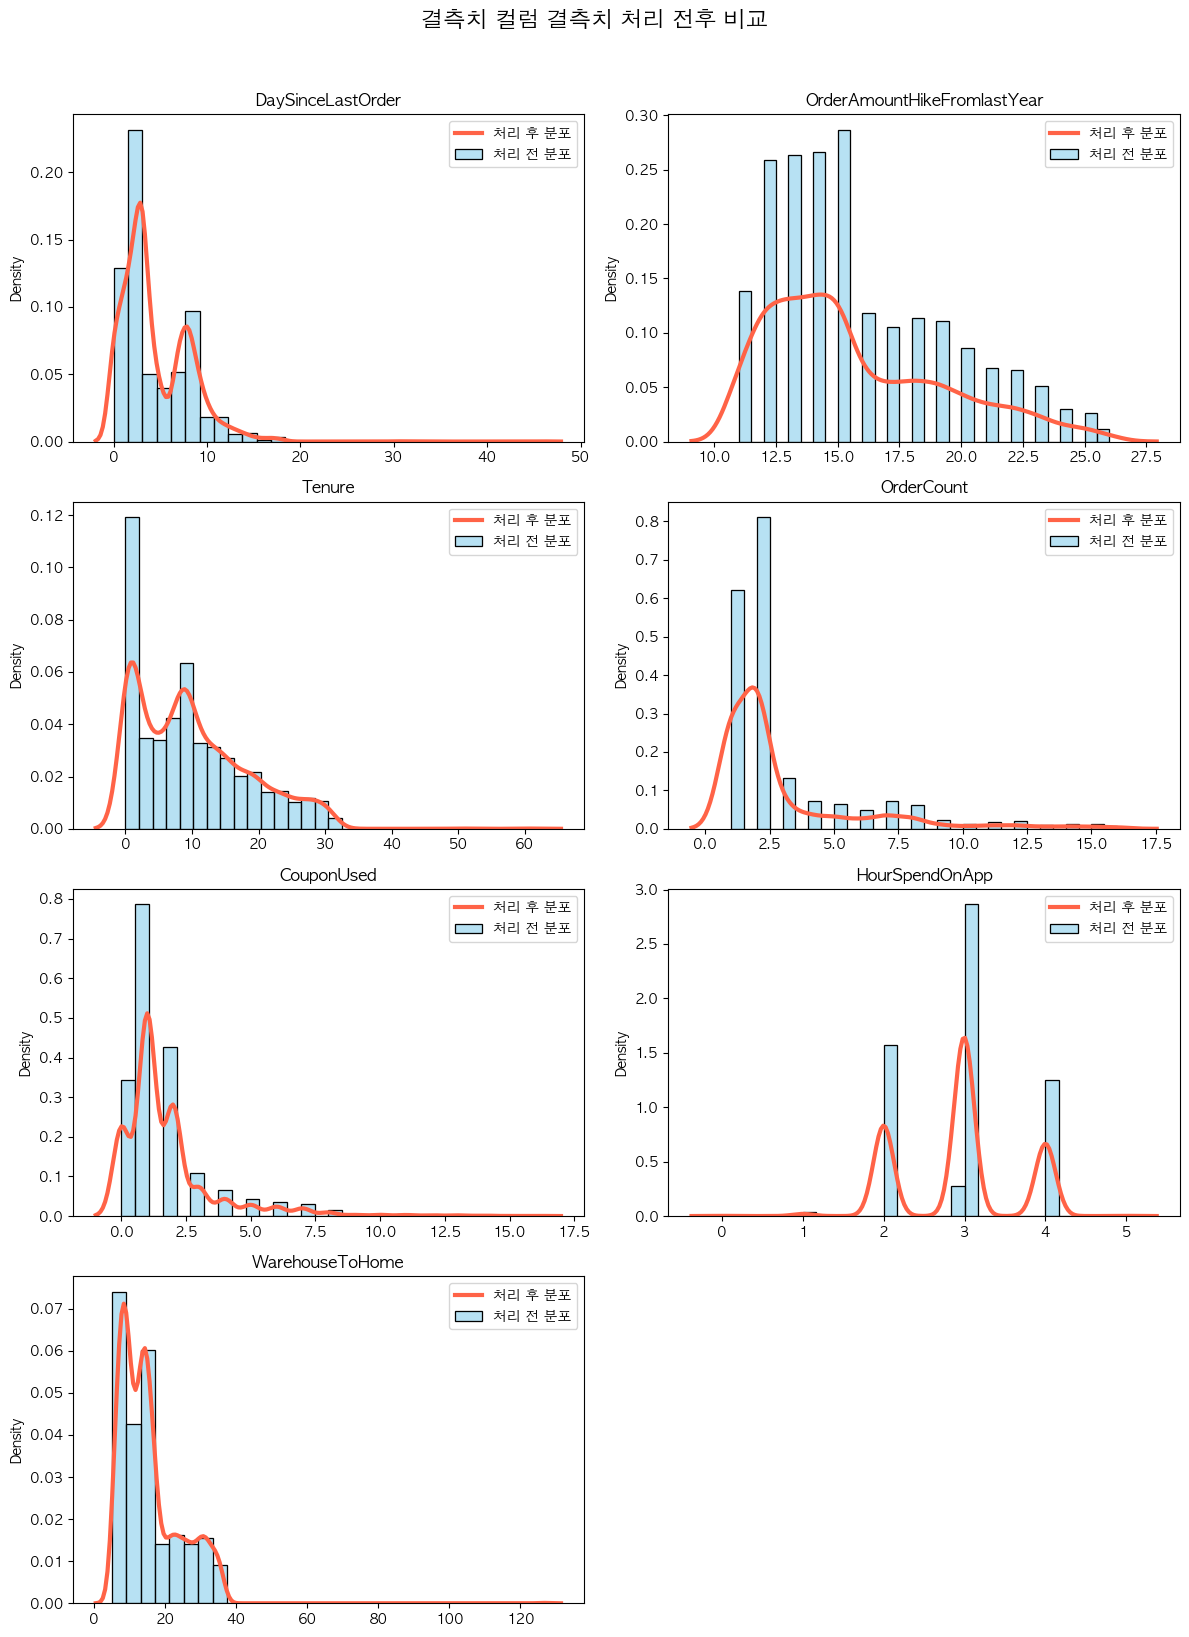

In [13]:
# ─────────────────────────────────────────────
# 4. 결측치 전, 후 비교
# ─────────────────────────────────────────────
after_sr = df[missing_cols].isnull().sum()

compare = pd.DataFrame({
    "처리 전": missing_sr,
    "처리 후": after_sr,
    "채워진 수": missing_sr - after_sr,
})
display(compare.style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

# ─────────────────────────────────────────────
# 5. 시각화
# ─────────────────────────────────────────────
all_missing_cols = missing_cols

n_cols = 2
n_rows = (len(all_missing_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle("결측치 컬럼 결측치 처리 전후 비교", fontsize=16, fontweight='bold', y=1.02)

axes = axes.flatten()

for i, col in enumerate(all_missing_cols):
    # Before: 원본 데이터 (막대)
    sns.histplot(df[col], bins=30, kde=False, ax=axes[i], 
                 color='skyblue', label='처리 전 분포', stat="density", alpha=0.6)
    
    # After: 결측치 처리 후 분포 (선)
    sns.kdeplot(df[col], ax=axes[i], color='tomato', 
                linewidth=3, label='처리 후 분포')
    
    axes[i].set_title(f"{col}")
    axes[i].legend(loc='upper right')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# 데이터 개수가 홀수일 경우 남는 빈 칸 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3. 이상치 처리

### 1. 이상치 확인

**1️⃣ 수치형 변수 이상치 탐색 결과**

- 수치형 변수 이상치 탐색 결과 ➡️ 이상치 처리 방법 결정
- 이상치/비율 : 전체 데이터 중 몇 개나 정삼 범위에 벗어났는지 확인 <br>
- 정상 상한(Upper) vs 최댓값 : 최댓값이 상한선보다 훨씬 크다면 꼬리가 아주 긴 데이터 

| 변수명 | 이상치 수/비율 | 정상 상한 | 실제 최댓값 | 꼬리 긴 정도 |
| --- | --- | --- | --- | --- |
| OrderCount | 703개 (12.49%) | 6.00 | 16.00 | ⭐⭐⭐ 매우 김 |
| CouponUsed| 629개 (11.17%) | 3.50 | 16.00 | ⭐⭐⭐ 매우 김 |
|NumberOfAddress|	397개 (7.05%) |	5.00|	6.00|	⭐ 약함 |


**2️⃣ 이상치 이탈률 판단 결과**

- 이상치 이탈률 판단 ➡️ 이상 처리 방향(유지/변환/삭제) 결정
- 차이 : (이상치 그룹의 이탈률) - (정상 그룹의 이탈률) <br>
- 판단 : <br>
  ★ 정보성: 이상치인 사람들의 이탈률이 정상인과 확연히 다르다면, 아주 중요한 단서.<br> 
  ▲ 분포왜곡: 이탈률 차이는 별로 없는데 숫자만 너무 많다면, 모델이 계산하기 편하게 모양만 다듬기 <br>

| 변수명 | 이상치 이탈률 | 정상 이탈률 | **차이** | 판단  |
| --- | --- | --- | --- | --- |
| OrderCount | 0.17 (17%) | 0.17 (17%) | 0.00 | ▲ 변환 (분포왜곡) |
| CouponUsed | 0.17 (17%) | 0.17 (17%) | 0.00 | ▲ 변환 (분포왜곡) |
| NumberOfDeviceRegistered | 0.20 (20%) | 0.17 (17%) | +0.03 | ▲ 변환 (분포왜곡) |


- 
  > 결론 : <br>
  > - `OrderCount` : 이상치 12.9%이지만, 이탈률 차이 0% -> 단순히 많이 사는 고객이지 이탈과 무관 -> 로그 변환
  > - `CouponUsed` : 아성차 11,17%이지만, 이탈률 차이 0% -> 쿠폰을 많이 사는 고객 ≠ 이탈 고객(오히려 마케팅 활용도 높은 고객일 수도) -> 로그 변환
  > - `NumberOfDeviceRegistered` : 이상치 7.05%이지만, 이탈률 차이 0.03% -> 앱 등록 많이 한 것과 이탈과 큰 연관 없음 -> 기존유지

In [14]:
# 이상치 확인
exclude = {'Churn', 'CustomerID'}
num_cols = [col for col in df.select_dtypes(include='number').columns if col not in exclude]
overall_churn = df["Churn"].mean()

outlier_info = {}   # 시각화에서 col 키로 접근
outlier_list = []   # 요약 테이블용
rows = []           # 판단 테이블용

for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    mask   = (df[col] < lower) | (df[col] > upper)
    n_out  = int(mask.sum())
    out_churn  = df.loc[mask,  "Churn"].mean() if n_out > 0 else 0.0
    norm_churn = df.loc[~mask, "Churn"].mean()
    diff       = out_churn - norm_churn

    outlier_info[col] = dict(
        lower=lower, upper=upper,
        n_out=n_out, pct=round(n_out / len(df) * 100, 2),
        out_churn=out_churn, norm_churn=norm_churn, diff=diff,
        mask=mask
    )

    outlier_list.append({
        '컬럼명'          : col,
        '이상치 수'        : n_out,
        '비율(%)'         : f"{n_out / len(df) * 100:.2f}%",
        '정상 하한(Lower)' : round(lower, 2),
        '최솟값'           : df[col].min(),
        '정상 상한(Upper)' : round(upper, 2),
        '최댓값'           : df[col].max()
    })

    if abs(diff) > 0.05:
        tag = "★ 정보성 (유지 권장)"
    elif n_out > 200:
        tag = "▲ 분포왜곡 (변환 권장)"
    else:
        tag = "○ 소량/무관"

    rows.append({
        '컬럼명'     : col,
        '이상치 이탈률': round(out_churn, 4),
        '정상 이탈률' : round(norm_churn, 4),
        '차이'       : round(diff, 4),
        '판단'       : tag
    })

# 피처-Churn 상관계수 (이후 시각화에서 사용)
corr_vals = df[num_cols + ["Churn"]].corr()["Churn"].drop("Churn")

# 이상치 수 기준 요약 테이블
df_outlier_summary = pd.DataFrame(outlier_list).sort_values(by='이상치 수', ascending=False)
print("📊 수치형 변수 이상치 탐색 결과(비율 >= 10%)")                # 표안에 문자열(string)이 일을 때 소수점
display(df_outlier_summary.reset_index(drop=True).style.format(subset=df_outlier_summary.select_dtypes(include='number').columns, formatter="{:.2f}")
                .set_properties(**{'text-align': 'left'})
                .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

# 이탈률 판단 테이블
df_outlier_judge = pd.DataFrame(rows).sort_values(by='차이', key=abs, ascending=False)
print("📋 이상치 이탈률 판단(차이 ±0.05(5%p))")
display(df_outlier_judge.reset_index(drop=True).style.format(subset=df_outlier_judge.select_dtypes(include='number').columns, formatter="{:.2f}")
                .set_properties(**{'text-align': 'left'})
                .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))


📊 수치형 변수 이상치 탐색 결과(비율 >= 10%)


,컬럼명,이상치 수,비율(%),정상 하한(Lower),최솟값,정상 상한(Upper),최댓값
0,OrderCount,703.00,12.49%,-2.00,1.00,6.00,16.00
1,CouponUsed,629.00,11.17%,-0.50,0.00,3.50,16.00
2,CashbackAmount,447.00,7.94%,71.00,0.00,271.00,325.00
3,NumberOfDeviceRegistered,397.00,7.05%,1.50,1.00,5.50,6.00
4,DaySinceLastOrder,62.00,1.10%,-5.50,0.00,14.50,46.00
5,OrderAmountHikeFromlastYear,33.00,0.59%,5.50,11.00,25.50,26.00
6,HourSpendOnApp,6.00,0.11%,0.50,0.00,4.50,5.00
7,Tenure,4.00,0.07%,-15.00,0.00,33.00,61.00
8,NumberOfAddress,4.00,0.07%,-4.00,1.00,12.00,22.00
9,WarehouseToHome,2.00,0.04%,-7.50,5.00,36.50,127.00


📋 이상치 이탈률 판단(차이 ±0.05(5%p))


,컬럼명,이상치 이탈률,정상 이탈률,차이,판단
0,NumberOfAddress,0.50,0.17,0.33,★ 정보성 (유지 권장)
1,HourSpendOnApp,0.00,0.17,-0.17,★ 정보성 (유지 권장)
2,Tenure,0.00,0.17,-0.17,★ 정보성 (유지 권장)
3,CityTier,0.00,0.17,-0.17,★ 정보성 (유지 권장)
4,WarehouseToHome,0.00,0.17,-0.17,★ 정보성 (유지 권장)
5,SatisfactionScore,0.00,0.17,-0.17,★ 정보성 (유지 권장)
6,Complain,0.00,0.17,-0.17,★ 정보성 (유지 권장)
7,CashbackAmount,0.04,0.18,-0.13,★ 정보성 (유지 권장)
8,OrderAmountHikeFromlastYear,0.06,0.17,-0.11,★ 정보성 (유지 권장)
9,DaySinceLastOrder,0.08,0.17,-0.09,★ 정보성 (유지 권장)


### 2. 이상치 분포 시각화

#### 1. Churn별 Feature 분포 비교 (<font style='color: Blue'>유지</font> / <font style='color: Red'>이탈</font>)
- 데이터 분포도 파악
  | 분포 파악 | 변수 및 해석 |
  |---|---|
  |상단에 점들 길게 늘어짐 | `OrderCount`➡️ 소수 고객이 몰아서 주문 <br> `CouponUsed` ➡️ 쿠폰 사용|
  |<font style='color: Blue'>유지</font>와 <font style='color: Red'>이탈</font>의 점들 위치한 높이 다름 | `CashbackAmount`➡️ 유지 고개들이 캐시백 많이 받아감 |

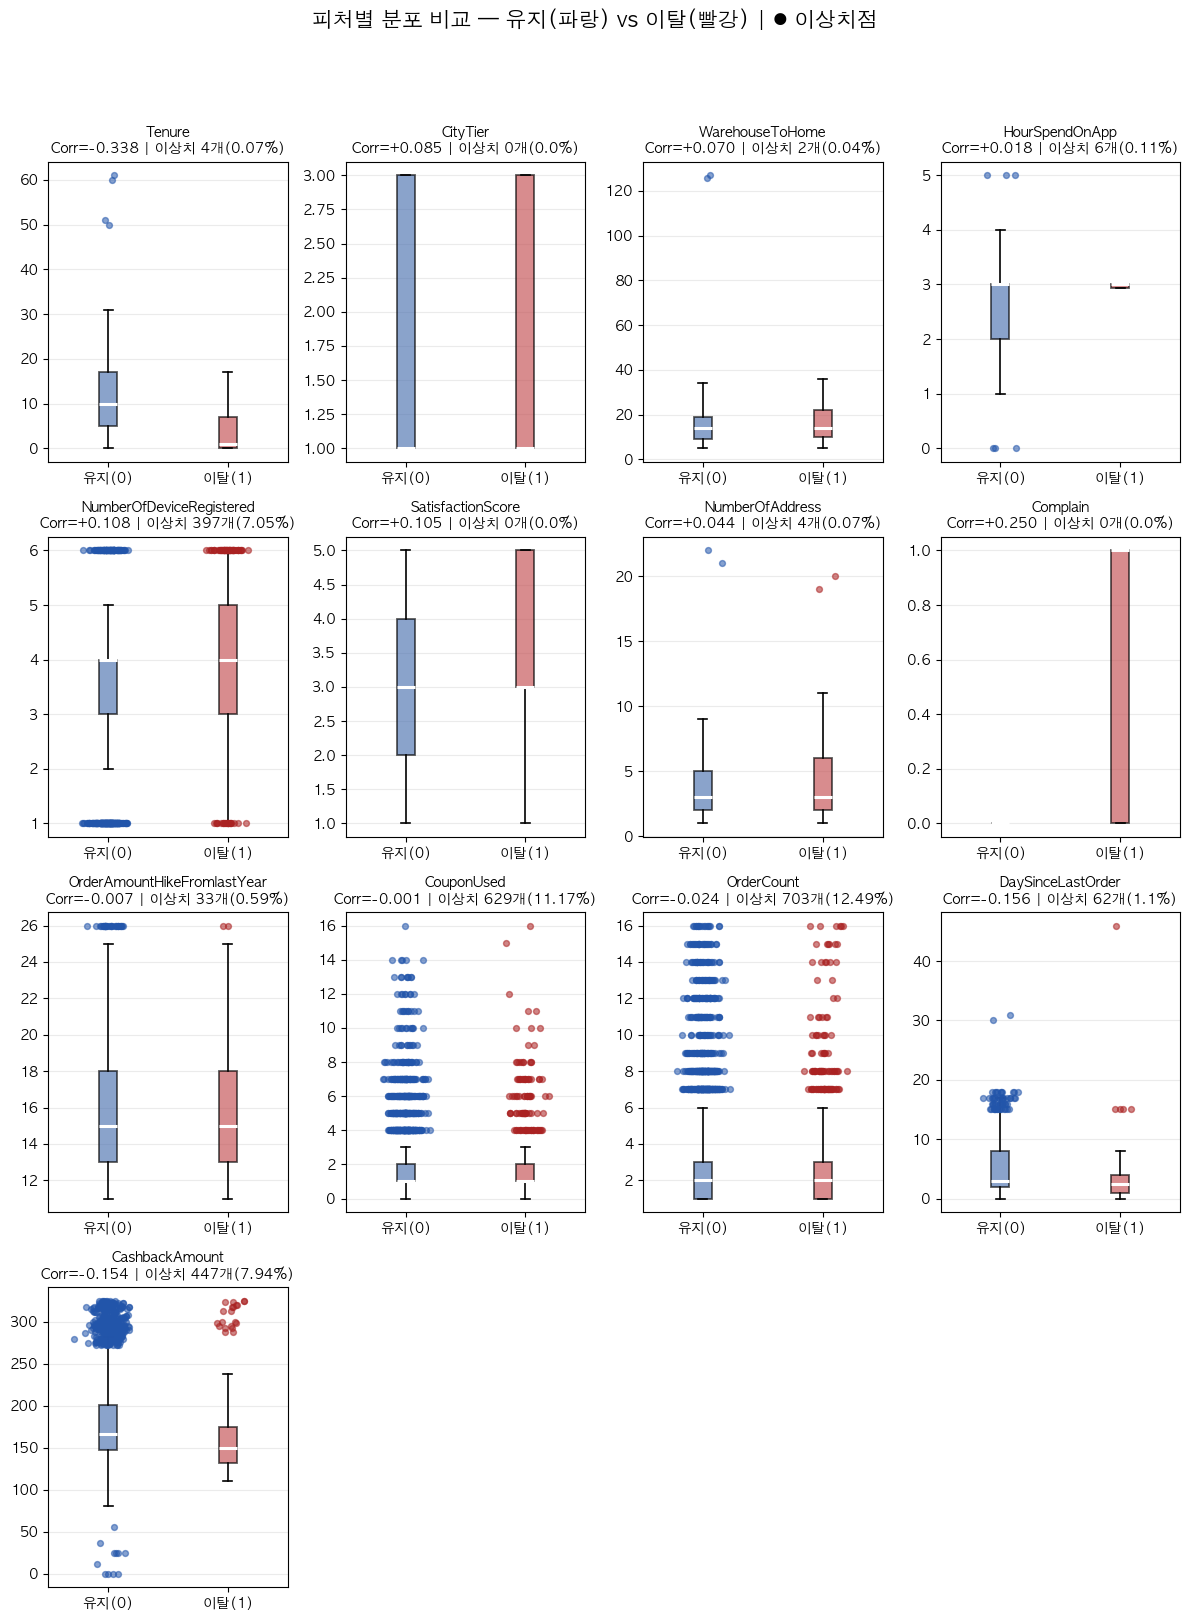

In [15]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 1】 Churn별 Feature 분포 비교 (유지=파랑 / 이탈=빨강)
# ════════════════════════════════════════════════════════════════════
N_COLS = 4
N_ROWS = -(-len(num_cols) // N_COLS)  # ceiling division
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(12, N_ROWS * 4))
fig.suptitle("피처별 분포 비교 — 유지(파랑) vs 이탈(빨강) | ● 이상치점",
             fontsize=15, fontweight="bold", y=1.01)
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    ax   = axes_flat[i]
    info = outlier_info[col]
    g0 = df[df["Churn"]==0][col]
    g1 = df[df["Churn"]==1][col]

    bp = ax.boxplot([g0, g1], patch_artist=True, labels=["유지(0)","이탈(1)"],
                    showfliers=False,
                    boxprops=dict(linewidth=1.3),
                    medianprops=dict(linewidth=2.2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    bp["boxes"][0].set_facecolor("#4C72B0"); bp["boxes"][0].set_alpha(0.65)
    bp["boxes"][1].set_facecolor("#C44E52"); bp["boxes"][1].set_alpha(0.65)
    bp["medians"][0].set_color("white")
    bp["medians"][1].set_color("white")

    # 이상치 점 overlay (원본 IQR 경계 기준)
    for j, (gdata, color) in enumerate([(g0,"#2255AA"),(g1,"#AA2222")], start=1):
        mask_g = (gdata < info["lower"]) | (gdata > info["upper"])
        outs   = gdata[mask_g]
        ax.scatter(np.random.normal(j, 0.07, size=len(outs)), outs,
                   color=color, s=18, alpha=0.55, zorder=4)

    corr_v = corr_vals[col]
    ax.set_title(f"{col}\nCorr={corr_v:+.3f} | 이상치 {info['n_out']}개({info['pct']}%)",
                 fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### 2. 이상치 이탈률 vs 정상 이탈률 비교 
- <font style='color: Red'>빨간색 막대(이상치 그룹)</font>와 <font style='color: Blue'>파란색 막대(정상 그룹)</font>의 높이 차이가 클수록 그 변수는 이탈 예측에 아주 중요한 힌트
  

  | 분포 파악 | 변수 및 해석 |
  |---|---|
  |<font style='color: Red'>이상치 그룹</font>(50%)> 정상 그룹 | `NumberOfAddress`➡️ 주소가 많은 고객은 이탈 위험이 매우 높음 |
  |<font style='color: Red'>이상치 그룹</font> 미존재(0%) | `Tenure`,`WarehouseToHome`,`HourSpendOnApp` ➡️ 비정상적으로 큰 수치의 고객은 100% 잔류

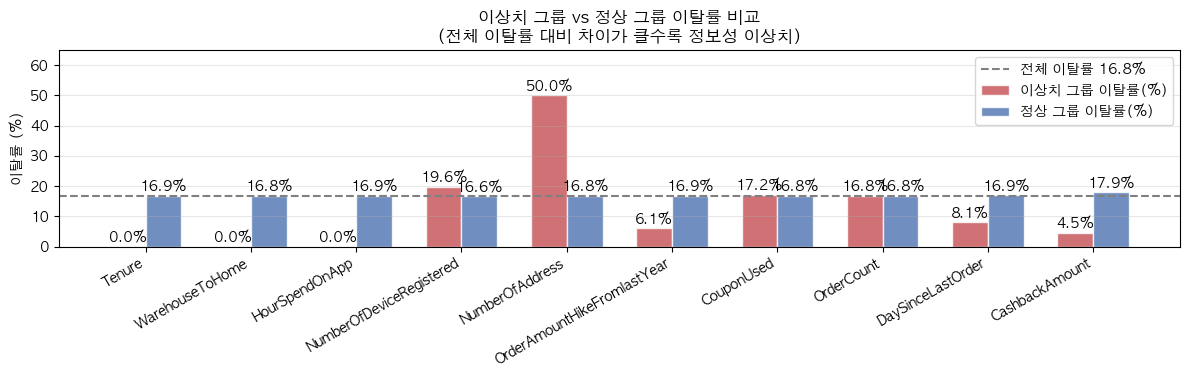

In [16]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 2】 이상치 이탈률 vs 정상 이탈률 비교
# ════════════════════════════════════════════════════════════════════
# 이상치 있는 컬럼만 추출
has_out = [(col, outlier_info[col]) for col in num_cols if outlier_info[col]["n_out"] > 0]
labels  = [c for c,_ in has_out]
out_rates  = [v["out_churn"]*100 for _,v in has_out]
norm_rates = [v["norm_churn"]*100 for _,v in has_out]

x     = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(12, 4))
b1 = ax.bar(x - width/2, out_rates,  width, label="이상치 그룹 이탈률(%)", color="#C44E52", alpha=0.8, edgecolor="white")
b2 = ax.bar(x + width/2, norm_rates, width, label="정상 그룹 이탈률(%)",   color="#4C72B0", alpha=0.8, edgecolor="white")
ax.axhline(overall_churn*100, color="gray", linestyle="--", linewidth=1.5,
           label=f"전체 이탈률 {overall_churn*100:.1f}%")

for bar in [*b1, *b2]:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("이탈률 (%)"); ax.set_ylim(0, 65)
ax.set_title("이상치 그룹 vs 정상 그룹 이탈률 비교\n(전체 이탈률 대비 차이가 클수록 정보성 이상치)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### 3. Feature-Churn 상관계수 + 이상치 비율 
- 어떤 변수가 이탈에 가장 큰 영향을 주는지 우선순위 파악
  

  | 분포 파악 | 변수 및 해석 |
  |---|---|
  |상관계수(-0.338)가 가장 높음| `Tenure`➡️ 유지 기간이 이탈을 막는 가장 강력한 요인 |
  |양의 상관관계(+0.250)가 가장 높음 | `Complain` ➡️ 불만이 많을수록 이탈할 확률 올라감 |

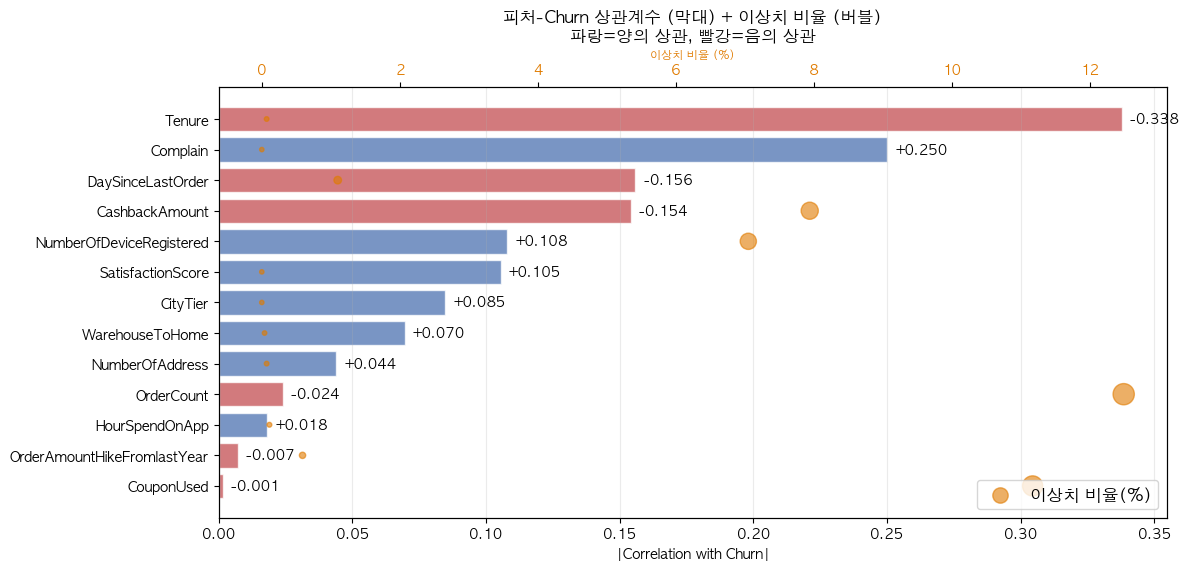

In [17]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 3】Feature-Churn 상관계수 + 이상치 비율 
# ════════════════════════════════════════════════════════════════════
corr_sorted = corr_vals.abs().sort_values(ascending=True)
pct_vals    = [outlier_info[col]["pct"] for col in corr_sorted.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ["#C44E52" if corr_vals[c] < 0 else "#4C72B0" for c in corr_sorted.index]
bars = ax.barh(corr_sorted.index, corr_sorted.values, color=colors_bar, alpha=0.75, edgecolor="white")

# 이상치 비율 버블 overlay
ax2 = ax.twiny()
ax2.scatter(pct_vals, range(len(corr_sorted)),
            s=[p*18+10 for p in pct_vals], color="#E07B00", alpha=0.6,
            label="이상치 비율(%)", zorder=5)
ax2.set_xlabel("이상치 비율 (%)", color="#E07B00", fontsize=8)
ax2.tick_params(axis="x", labelcolor="#E07B00")
ax2.legend(loc="lower right", fontsize=12)

for bar, val, col in zip(bars, corr_sorted.values, corr_sorted.index):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f"{corr_vals[col]:+.3f}", va="center", fontsize=10)

ax.set_xlabel("|Correlation with Churn|", fontsize=10)
ax.set_title("피처-Churn 상관계수 (막대) + 이상치 비율 (버블)\n파랑=양의 상관, 빨강=음의 상관",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### 3-3. 이상치 처리

- 이상치 분포 왜곡 `CouponUsed`,`OrderCount`,`NumberOfDeviceRegistered` 
- `CouponUsed`,`OrderCount`는 숫자 범위가 매우 큼 -> 로그변환 
- `NumberOfDeviceRegistered`는 값의 범위가 좁고 딱딱 끊어지는 숫자 -> 기존 유지

In [18]:
#  OrderCount와 CouponUsed 로그변환(왜도 완화)
df_encoded = df.copy()

df_encoded['OrderCount_log'] = np.log1p(df['OrderCount'])
df_encoded['CouponUsed_log'] = np.log1p(df['CouponUsed'])

df_encoded = df_encoded.drop(columns=['OrderCount', 'CouponUsed', 'CustomerID'], errors='ignore')

# 로그변환한 것 -> df_encoded 담음 (df 복사본, 컬럼 수 동일)
df_encoded.describe().T.style.format("{:.2f}").set_properties(**{'text-align': 'left'})\
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
                        

,count,mean,std,min,25%,50%,75%,max
Churn,5630.00,0.17,0.37,0.00,0.00,0.00,0.00,1.00
Tenure,5630.00,10.13,8.36,0.00,3.00,9.00,15.00,61.00
CityTier,5630.00,1.65,0.92,1.00,1.00,1.00,3.00,3.00
WarehouseToHome,5630.00,15.57,8.35,5.00,9.00,14.00,20.00,127.00
HourSpendOnApp,5630.00,2.93,0.71,0.00,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,5630.00,3.69,1.02,1.00,3.00,4.00,4.00,6.00
SatisfactionScore,5630.00,3.07,1.38,1.00,2.00,3.00,4.00,5.00
NumberOfAddress,5630.00,4.21,2.58,1.00,2.00,3.00,6.00,22.00
Complain,5630.00,0.28,0.45,0.00,0.00,0.00,1.00,1.00
OrderAmountHikeFromlastYear,5630.00,15.67,3.59,11.00,13.00,15.00,18.00,26.00


# 데이터 인코딩

### 1. One-Hot Encoding

- `CityTier`는 수치형이지만 단순한 분류일 뿐, 숫자가 순서나 크기가 상관없기에 컴퓨터가 숫자가 클수록 더 중요하다 판단할 수 있어 인코딩함
- One-Hot Encoding을 하면 각 등급이 `CityTier_1`, `CityTier_2`, `CityTier_3` 독립된 컬럼이 되고, 값은 오직 0과 1로만 표현됨
- 이제 모델은 각 등급을 <mark style='background-color: LemonChiffon'>"크기가 있는 숫자"가 아닌 "서로 다른 상태"</mark>로 인식

In [19]:
df_encoded['CityTier'] = df['CityTier'].astype(str)

# prefix를 주면 컬럼명이 'CityTier_1', 'CityTier_2' 식으로 생성되어 구분이 편합니다.
df_encoded = pd.get_dummies(df_encoded, columns=['CityTier'], prefix='CityTier')

# bool → int 변환
bool_cols = df_encoded.select_dtypes(include='bool').columns
for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(int)
city_tier_cols = [col for col in df_encoded.columns if 'CityTier' in col]

print("✅ df_encoded 내 CityTier 관련 컬럼 목록:")
display(df_encoded[city_tier_cols].head())

✅ df_encoded 내 CityTier 관련 컬럼 목록:


,CityTier_1,CityTier_2,CityTier_3
0,0,0,1
1,1,0,0
2,1,0,0
3,0,0,1
4,1,0,0


### 2. 라벨 인코딩 (범주형 -> 수치화)

In [20]:
# ─────────────────────────────────────────────
# 6. 범주형 -> 수치화 
# ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    "PreferredLoginDevice",  # Computer / Phone
    "PreferredPaymentMode",  # Cash on Delivery / Credit Card / Debit Card / E wallet / UPI
    "Gender",                # Female / Male
    "PreferedOrderCat",      # Fashion / Grocery / Laptop & Accessory / Mobile / Others
    "MaritalStatus",         # Divorced / Married / Single
]

# Before: 원본 데이터 (범주형 포함, df 보존) 
print("🔈Before — 원본 데이터 (범주형 포함, df 유지)")

display(df[cat_cols].head(5).style.set_properties(**{'text-align': 'left'})
                    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
print(f"원본 전체 컬럼 수: {df.shape[1]}개  |  데이터 크기: {df.shape}")


# Label Encoding → df_encoded (df 복사본, 컬럼 수 동일)
label_encoders = {}
encoding_map   = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    encoding_map[col]   = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

# print(le.classes_)

🔈Before — 원본 데이터 (범주형 포함, df 유지)


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,Phone,Debit Card,Female,Laptop & Accessory,Single
1,Phone,UPI,Male,Mobile,Single
2,Phone,Debit Card,Male,Mobile,Single
3,Phone,Debit Card,Male,Laptop & Accessory,Single
4,Phone,Credit Card,Male,Mobile,Single


원본 전체 컬럼 수: 20개  |  데이터 크기: (5630, 20)


In [21]:
# After: 수치형 변환 데이터
print("🔊After  — 수치형 변환 데이터 (df_encoded, 컬럼 수 동일)")

display(df_encoded[cat_cols].head(5).style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))
print(f"컬럼 수: {df_encoded.shape[1]}개  |  데이터 크기: {df_encoded.shape}")

print()
print("📋 인코딩 매핑:")
for col, mapping in encoding_map.items():
    print(f"  {col:23s}: {mapping}")

🔊After  — 수치형 변환 데이터 (df_encoded, 컬럼 수 동일)


,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
0,1,2,0,2,2
1,1,4,1,3,2
2,1,2,1,3,2
3,1,2,1,2,2
4,1,1,1,3,2


컬럼 수: 21개  |  데이터 크기: (5630, 21)

📋 인코딩 매핑:
  PreferredLoginDevice   : {'Computer': 0, 'Phone': 1}
  PreferredPaymentMode   : {'COD': 0, 'Credit Card': 1, 'Debit Card': 2, 'E wallet': 3, 'UPI': 4}
  Gender                 : {'Female': 0, 'Male': 1}
  PreferedOrderCat       : {'Fashion': 0, 'Grocery': 1, 'Laptop & Accessory': 2, 'Mobile': 3, 'Others': 4}
  MaritalStatus          : {'Divorced': 0, 'Married': 1, 'Single': 2}


In [22]:
df_encoded

,Churn,Tenure,PreferredLoginDevice,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,...,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,DaySinceLastOrder,CashbackAmount,OrderCount_log,CouponUsed_log,CityTier_1,CityTier_2,CityTier_3
0,1,4.0,1,6.0,2,0,3.000000,3,2,2,...,9,1,11.0,5.0,160,0.693147,0.693147,0,0,1
1,1,9.0,1,8.0,4,1,3.000000,4,3,3,...,7,1,15.0,0.0,121,0.693147,0.000000,1,0,0
2,1,9.0,1,30.0,2,1,2.000000,4,3,3,...,6,1,14.0,3.0,120,0.693147,0.000000,1,0,0
3,1,0.0,1,15.0,2,1,2.000000,4,2,5,...,8,0,23.0,3.0,134,0.693147,0.000000,0,0,1
4,1,0.0,1,12.0,1,1,2.931535,3,3,5,...,3,0,11.0,3.0,130,0.693147,0.693147,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.0,0,30.0,1,1,3.000000,2,2,1,...,6,0,18.0,4.0,151,1.098612,0.693147,1,0,0
5626,0,13.0,1,13.0,1,1,3.000000,5,0,5,...,6,0,16.0,3.0,225,1.098612,0.693147,1,0,0
5627,0,1.0,1,11.0,2,1,3.000000,2,2,4,...,3,1,21.0,4.0,186,1.098612,0.693147,1,0,0
5628,0,23.0,0,9.0,1,1,4.000000,5,2,4,...,4,0,15.0,9.0,179,1.098612,1.098612,0,0,1


# 데이터 분리 

- Train / Validation / Test Split (60 / 20 / 20) <br>
- 타겟 변수: `Churn` (0=유지, 1=이탈)  
- 클래스 불균형 유지를 위해 모든 분할에 `stratify=y` 적용

In [23]:
# ─────────────────────────────────────────────────────────────────────
# Train / Validation / Test  =  60% / 20% / 20%
# ─────────────────────────────────────────────────────────────────────
SEED = 42

# CustomerID 제거, 타겟 분리
X = df_encoded.drop(columns=["CustomerID", "Churn"], errors="ignore")
y = df_encoded["Churn"]

# Step 1: 전체 → Train(60%) + Temp(40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=SEED
)

# Step 2: Temp(40%) → Validation(20%) + Test(20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,          # 40% × 50% = 20%
    stratify=y_temp,
    random_state=SEED
)

print("🎯 타겟 변수: Churn  (0=유지, 1=이탈)")
print()
print(f"{'세트':<9} {'행 수':>8} {'이탈(1)':>8} {'이탈률':>7}")
print("-" * 42)

# 원본 타겟 데이터 보존을 위해 이름을 다르게 설정
datasets = [("Train(60%)", y_train), ("Val(20%)", y_val), ("Test(20%)", y_test)]
for name, y_set in datasets:
    print(f"{name:<12} {len(y_set):>8,} {y_set.sum():>8} {y_set.mean()*100:>8.1f}%")

# 원본 전체 데이터(y)의 합계를 출력
total_y = pd.concat([y_train, y_val, y_test]) 
print("-" * 42)
print(f"{'전체':<11} {len(total_y):>8,} {total_y.sum():>8} {total_y.mean()*100:>8.1f}%")
print()

# f-string 오타 수정: {X_train.shape[1]}
print(f"🧨 피처 수: {X_train.shape[1]}개")
print(f"   피처 목록:\n {X_train.columns}")

🎯 타겟 변수: Churn  (0=유지, 1=이탈)

세트             행 수    이탈(1)     이탈률
------------------------------------------
Train(60%)      3,378      569     16.8%
Val(20%)        1,126      190     16.9%
Test(20%)       1,126      189     16.8%
------------------------------------------
전체             5,630      948     16.8%

🧨 피처 수: 20개
   피처 목록:
 Index(['Tenure', 'PreferredLoginDevice', 'WarehouseToHome',
       'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'DaySinceLastOrder', 'CashbackAmount',
       'OrderCount_log', 'CouponUsed_log', 'CityTier_1', 'CityTier_2',
       'CityTier_3'],
      dtype='object')


# 스케일링 분석

## 1. 스케일러 개요 및 선택 기준

**분석 목적** : StandardScaler, MinMaxScaler, RobustScaler 3가지를 비교하여 최적의 스케일러 선택

| 스케일러 | 원리  | 이 데이터에서 특징 |
| --- | --- | --- |
| StandardScaler | 평균=0, 표준편차=1 | 이상치에 민감 — 평균/표준편차가 이상치에 끌려감 |
| MinMaxScaler | \[0,1\] 범위로 압축 | 이상치에 가장 민감 — 이상치 하나가 전체 범위 결정 |
| RobustScaler | 중앙값=0, IQR 사용 | 이상치에 강건 — 이 데이터에 가장 유리 |


In [24]:
# 스케일러 비교 분석

# 스케일링 대상 컬럼 (수치형만)
scale_cols = X_train.select_dtypes(include=["number"]).columns.difference(['CustomerID']).tolist()

# 원본 데이터 백업 (분포 비교용)
X_train_orig = X_train[scale_cols].copy()

# ─── 3가지 스케일러 적용 ───────────────────────────────────────────────────
scaler_standard = StandardScaler()
scaler_minmax  = MinMaxScaler()
scaler_robust  = RobustScaler()

# fit_transform (train), transform (val/test) - Data Leakage 방지
X_train_std = pd.DataFrame(scaler_standard.fit_transform(X_train[scale_cols]),
                            columns=scale_cols, index=X_train.index)
X_val_std   = pd.DataFrame(scaler_standard.transform(X_val[scale_cols]),
                            columns=scale_cols, index=X_val.index)
X_test_std  = pd.DataFrame(scaler_standard.transform(X_test[scale_cols]),
                            columns=scale_cols, index=X_test.index)

X_train_minmax = pd.DataFrame(scaler_minmax.fit_transform(X_train[scale_cols]),
                               columns=scale_cols, index=X_train.index)
X_val_minmax   = pd.DataFrame(scaler_minmax.transform(X_val[scale_cols]),
                               columns=scale_cols, index=X_val.index)
X_test_minmax  = pd.DataFrame(scaler_minmax.transform(X_test[scale_cols]),
                               columns=scale_cols, index=X_test.index)

X_train_robust = pd.DataFrame(scaler_robust.fit_transform(X_train[scale_cols]),
                               columns=scale_cols, index=X_train.index)
X_val_robust   = pd.DataFrame(scaler_robust.transform(X_val[scale_cols]),
                               columns=scale_cols, index=X_val.index)
X_test_robust  = pd.DataFrame(scaler_robust.transform(X_test[scale_cols]),
                               columns=scale_cols, index=X_test.index)

print("✅ 3가지 스케일러 적용 완료")
print(f"   - StandardScaler: 평균=0, 표준편차=1")
print(f"   - MinMaxScaler  : 범위=[0, 1]")
print(f"   - RobustScaler  : 중앙값=0, IQR 사용 (이상치 강건)")
print()
print(f"스케일링 대상 컬럼: {len(scale_cols)}개")

✅ 3가지 스케일러 적용 완료
   - StandardScaler: 평균=0, 표준편차=1
   - MinMaxScaler  : 범위=[0, 1]
   - RobustScaler  : 중앙값=0, IQR 사용 (이상치 강건)

스케일링 대상 컬럼: 20개


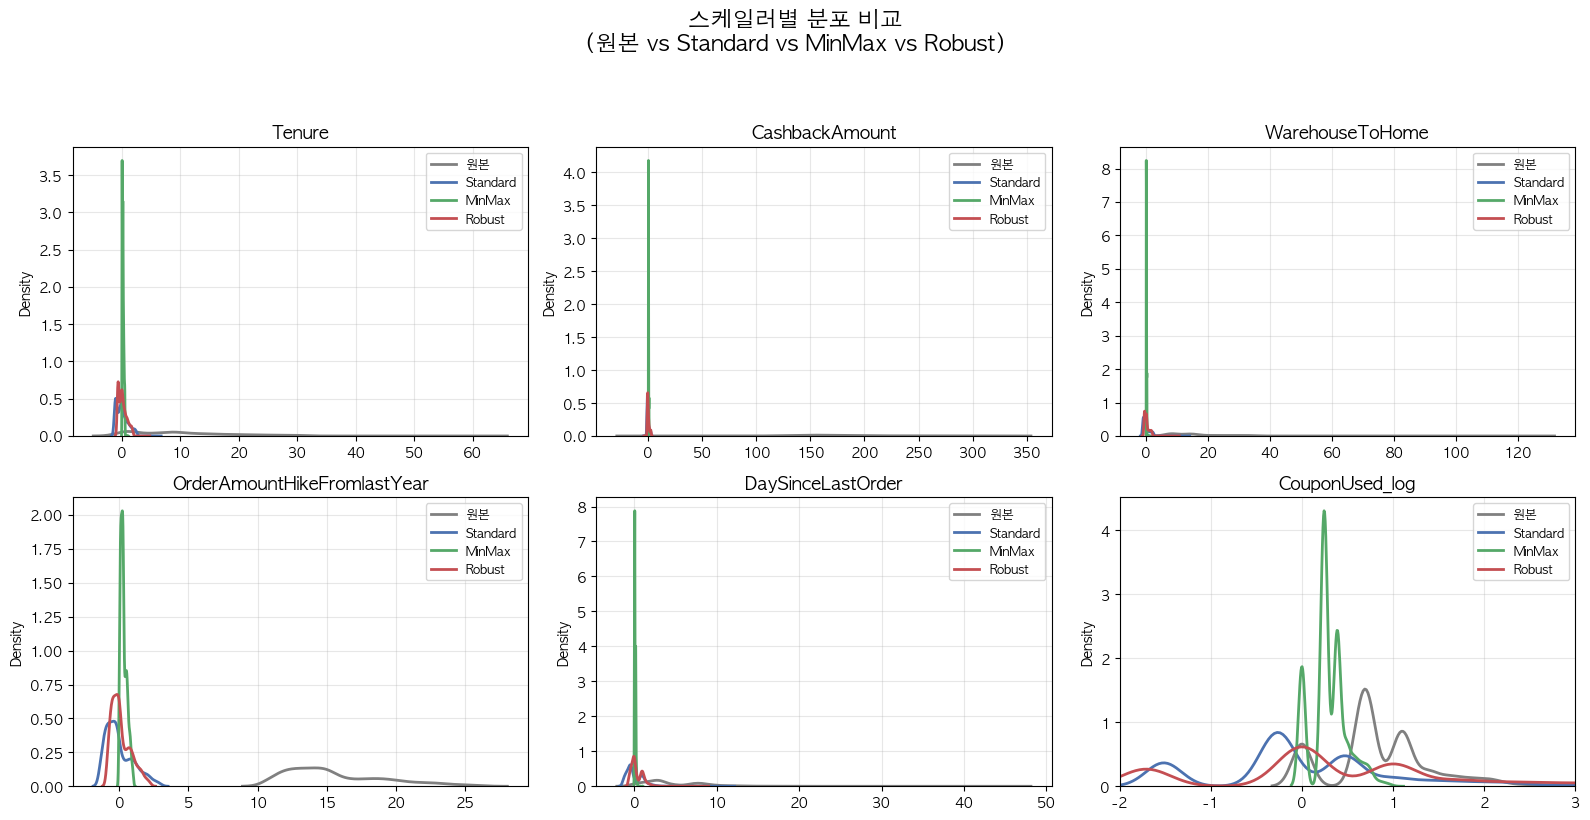

In [25]:
# ═══════════════════════════════════════════════════════════════════════════
# 【Fig 1: 스케일러별 분포 비교 (Subplot)】
# ═══════════════════════════════════════════════════════════════════════════

# 분포 변화가 큰 대표 변수 선택 
representative_cols = ["Tenure", "CashbackAmount", "WarehouseToHome",
                       "OrderAmountHikeFromlastYear", "DaySinceLastOrder", "CouponUsed_log"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("스케일러별 분포 비교\n(원본 vs Standard vs MinMax vs Robust)",
             fontsize=16, fontweight="bold", y=1.02)

for idx, col in enumerate(representative_cols):
    ax = axes[idx // 3, idx % 3]

    # 4가지 분포 겹쳐서 그리기 (KDE)
    sns.kdeplot(X_train_orig[col],    ax=ax, color="gray",    label="원본", linewidth=2, linestyle="-")
    sns.kdeplot(X_train_std[col],     ax=ax, color="#4C72B0", label="Standard", linewidth=2, linestyle="-")
    sns.kdeplot(X_train_minmax[col],  ax=ax, color="#55A868", label="MinMax", linewidth=2, linestyle="-")
    sns.kdeplot(X_train_robust[col],  ax=ax, color="#C44E52", label="Robust", linewidth=2, linestyle="-")

    ax.set_title(f"{col}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
plt.xlim(-2, 3)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

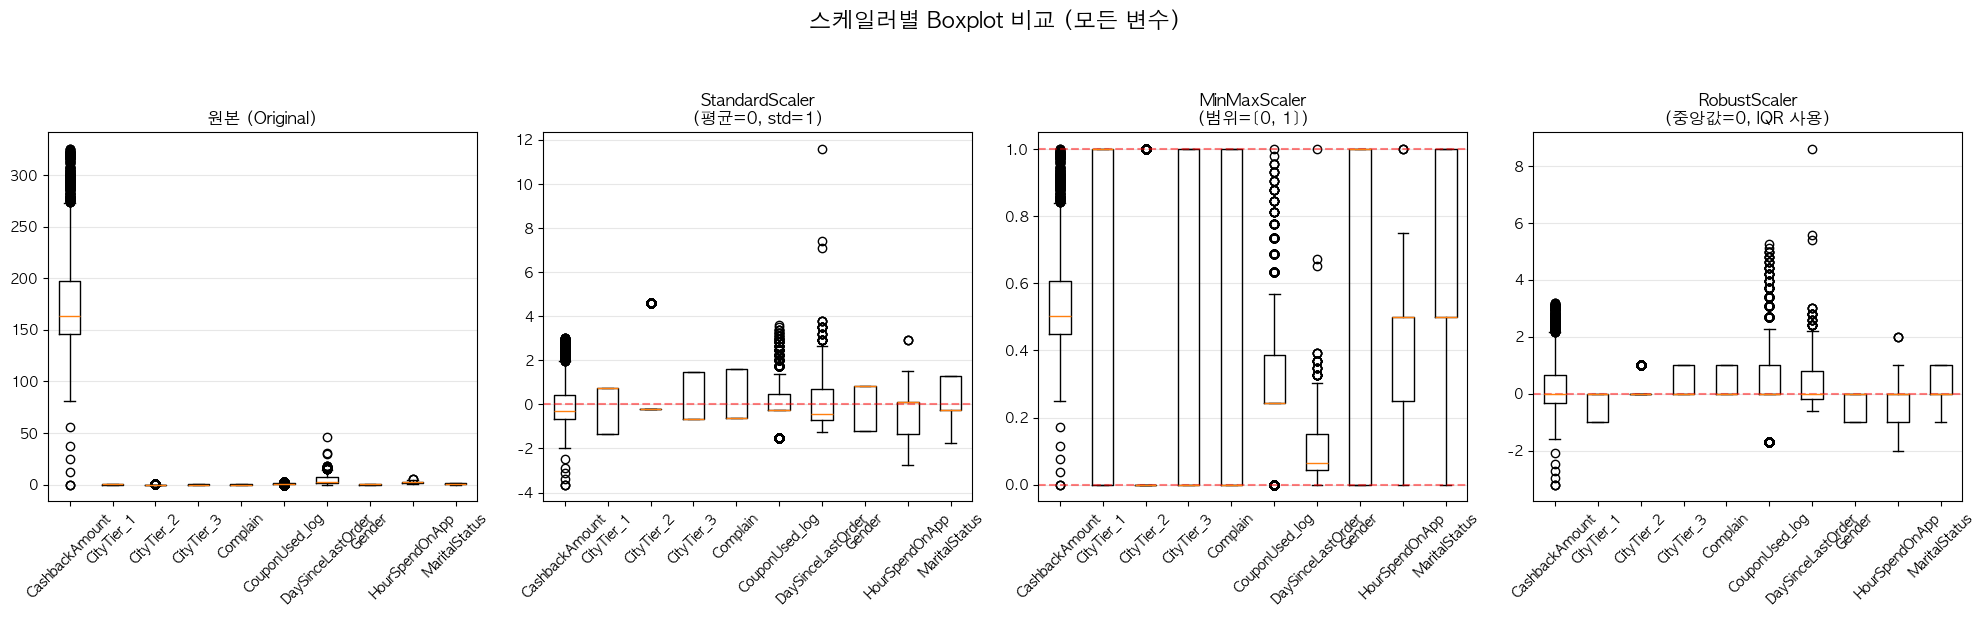

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# 【Fig 2: Boxplot 비교 - 스케일러별 스케일 차이 확인】
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("스케일러별 Boxplot 비교 (모든 변수)", fontsize=16, fontweight="bold", y=1.02)

# 원본
axes[0].boxplot([X_train_orig[col] for col in scale_cols[:10]],
                labels=scale_cols[:10], vert=True)
axes[0].set_title("원본 (Original)", fontsize=12, fontweight="bold")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Standard
axes[1].boxplot([X_train_std[col] for col in scale_cols[:10]],
                labels=scale_cols[:10], vert=True)
axes[1].set_title("StandardScaler\n(평균=0, std=1)", fontsize=12, fontweight="bold")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5) 

# MinMax
axes[2].boxplot([X_train_minmax[col] for col in scale_cols[:10]],
                labels=scale_cols[:10], vert=True)
axes[2].set_title("MinMaxScaler\n(범위=[0, 1])", fontsize=12, fontweight="bold")
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)
axes[2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[2].axhline(1, color='red', linestyle='--', alpha=0.5)

# Robust
axes[3].boxplot([X_train_robust[col] for col in scale_cols[:10]],
                labels=scale_cols[:10], vert=True)
axes[3].set_title("RobustScaler\n(중앙값=0, IQR 사용)", fontsize=12, fontweight="bold")
axes[3].tick_params(axis='x', rotation=45)
axes[3].grid(axis='y', alpha=0.3)
axes[3].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 2. 스케일러 선택 결과

### 성능 비교 결과

**선택 기준**: AUC 점수 기준 최고 성능 + Tree 모델 특성 고려

| 스케일러 | Accuracy | Precision | Recall | F1 | AUC |
|----------|----------|-----------|--------|------|------|
| 원본 | 0.9645 | 0.9071 | 0.8783 | 0.8925 | 0.9740 |
| **StandardScaler** | 0.9645 | 0.9062 | 0.8783 | 0.8920 | **0.9750** |
| MinMaxScaler | 0.9638 | 0.9071 | 0.8737 | 0.8901 | 0.9742 |
| RobustScaler | 0.9638 | 0.9071 | 0.8737 | 0.8901 | 0.9741 |

### 최종 선택: StandardScaler

**선택 근거**:
1. **AUC 최고** (0.9750)
2. Tree 모델(LightGBM)은 스케일링에 영향 거의 없음
3. 향후 Linear/SVM 모델로 확장 시 안정적
4. 분포 형태 왜곡 없이 일관된 변환

## 3. 스케일링 처리

In [27]:
# 수치형 스케일링
scaling_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 
                'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'DaySinceLastOrder','CashbackAmount',
                'OrderCount_log', 'CouponUsed_log']

scaler = StandardScaler()

# [중요] 학습 데이터(X_train)로만 기준을 잡습니다.
X_train[scaling_cols] = scaler.fit_transform(X_train[scaling_cols])

# [중요] 테스트 데이터(X_test)는 학습 데이터의 기준을 '그대로' 적용만 합니다.
X_test[scaling_cols] = scaler.transform(X_test[scaling_cols])
X_val[scaling_cols] = scaler.transform(X_val[scaling_cols])

print(f"📶학습 데이터 비율: \n{y_train.value_counts(normalize=True)}\n")
print(f"📶테스트 데이터 비율: \n{y_test.value_counts(normalize=True)}\n")
print(f"📶평가 데이터 비율: \n{y_val.value_counts(normalize=True)}\n")
      
      
print(f"   스케일링 컬럼 수: {len(scaling_cols)}개")


display(X_train[scaling_cols].describe().T.round(4).style.format("{:.3f}").set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))


📶학습 데이터 비율: 
Churn
0    0.831557
1    0.168443
Name: proportion, dtype: float64

📶테스트 데이터 비율: 
Churn
0    0.832149
1    0.167851
Name: proportion, dtype: float64

📶평가 데이터 비율: 
Churn
0    0.831261
1    0.168739
Name: proportion, dtype: float64

   스케일링 컬럼 수: 11개


,count,mean,std,min,25%,50%,75%,max
Tenure,3378.000,-0.000,1.000,-1.211,-0.852,-0.132,0.588,6.107
WarehouseToHome,3378.000,0.000,1.000,-1.278,-0.794,-0.191,0.534,13.458
HourSpendOnApp,3378.000,0.000,1.000,-2.739,-1.322,0.095,0.095,2.929
NumberOfDeviceRegistered,3378.000,0.000,1.000,-2.618,-0.674,0.298,0.298,2.243
SatisfactionScore,3378.000,0.000,1.000,-1.473,-0.754,-0.036,0.683,1.401
NumberOfAddress,3378.000,0.000,1.000,-1.253,-0.867,-0.480,0.678,6.859
OrderAmountHikeFromlastYear,3378.000,-0.000,1.000,-1.304,-0.739,-0.174,0.673,2.932
DaySinceLastOrder,3378.000,0.000,1.000,-1.254,-0.696,-0.417,0.699,11.582
CashbackAmount,3378.000,-0.000,1.000,-3.641,-0.642,-0.293,0.406,3.035
OrderCount_log,3378.000,0.000,1.000,-0.970,-0.970,-0.214,0.322,3.018


In [28]:
X_train
# X_train.shape

,Tenure,PreferredLoginDevice,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,DaySinceLastOrder,CashbackAmount,OrderCount_log,CouponUsed_log,CityTier_1,CityTier_2,CityTier_3
5040,-0.491603,0,0.534075,4,0,1.512159,1.270527,3,0.682600,1,-0.480483,0,1.520099,-0.416730,-0.374779,0.321899,0.987612,1,0,0
2219,-0.851515,1,-0.311392,2,1,-1.321781,-0.673681,2,-0.035949,1,-0.866745,0,-0.738859,1.257459,-0.867731,1.833098,1.390645,1,0,0
38,2.387695,1,1.741883,2,1,-1.321781,-1.645785,0,-0.754498,1,-0.094221,1,0.108250,-0.137698,0.344109,-0.969808,-0.264323,1,0,0
574,1.787841,1,-1.156858,2,1,0.095189,-0.673681,1,-0.754498,0,-0.480483,0,-0.174120,0.978428,1.925664,1.613605,-0.264323,1,0,0
2750,-0.731545,0,0.050951,1,0,-1.321781,-0.673681,0,-0.035949,1,0.292041,0,1.237729,-0.416730,0.672744,0.737735,0.987612,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4174,-1.091457,1,1.862664,2,1,0.095189,1.270527,3,-0.035949,2,1.064565,1,-0.174120,-0.137698,-0.662334,-0.214208,-0.264323,1,0,0
5038,0.708104,0,-0.794515,1,1,1.512159,-1.645785,2,1.401150,1,1.837089,0,0.390620,-0.137698,0.220871,-0.214208,0.468012,0,1,0
1384,-0.491603,0,-1.156858,2,0,-1.321781,-2.617889,2,1.401150,1,-0.480483,0,0.955360,-0.416730,-0.477477,-0.969808,-1.516257,0,0,1
4026,2.267724,1,-0.794515,0,1,1.512159,1.270527,3,-1.473047,1,2.223351,0,1.520099,0.141333,-0.518557,-0.214208,-0.264323,1,0,0


# 상관관계 분석
### 1. 변수 간 상관관계 분석

- 상관계수($r$) 크기에 따른 일반적인 해석
  
| 상관계수 범위 | 해석 | 대응 전략 |
| --- | --- | --- |
| 0.7 ~ 1.0 | 매우 강한 상관관계 | 두 변수가 거의 같은 정보를 담고 있음. (하나를 지우는 **차원축소** 고려) |
| 0.4 ~ 0.7 | 뚜렷한 상관관계 | 모델 예측에 핵심적인 피처가 될 가능성이 매우 높음. |
| 0.2 ~ 0.4 | 약한 상관관계 | 단독으로는 힘이 부족할 수 있지만, 다른 변수와 결합하면 유의미함. |
| 0.1 ~ 0.2 | 무시해도 좋은 수준 | 비즈니스 로직상 중요하지 않다면 삭제를 고민해 볼 수 있음. |
| 0.0 ~ 0.1 | 거의 관계없음 | 사실상 관련이 없는 변수들임. |

**분석 목적:**
- 고객 이탈(Churn)과 각 변수 간의 상관관계를 파악
- 변수들 간의 다중공선성(Multicollinearity) 문제 탐지
- 상관관계가 높은 변수들을 그룹으로 묶어 해석

#### 1. Feature X Feature + Feature X Churn - Feature간 상관관계 + Churn과의 상관관계

Feature X Churn 관계 (Churn 행)
- Tenure (-0.34) : 서비스에 익숙해진 고객 이탈률 적음
- Complain (0.25) : 서비스 불만 제기 시, 이탈 위험 큼 
- DaySinceLastOrder (-0.15) 

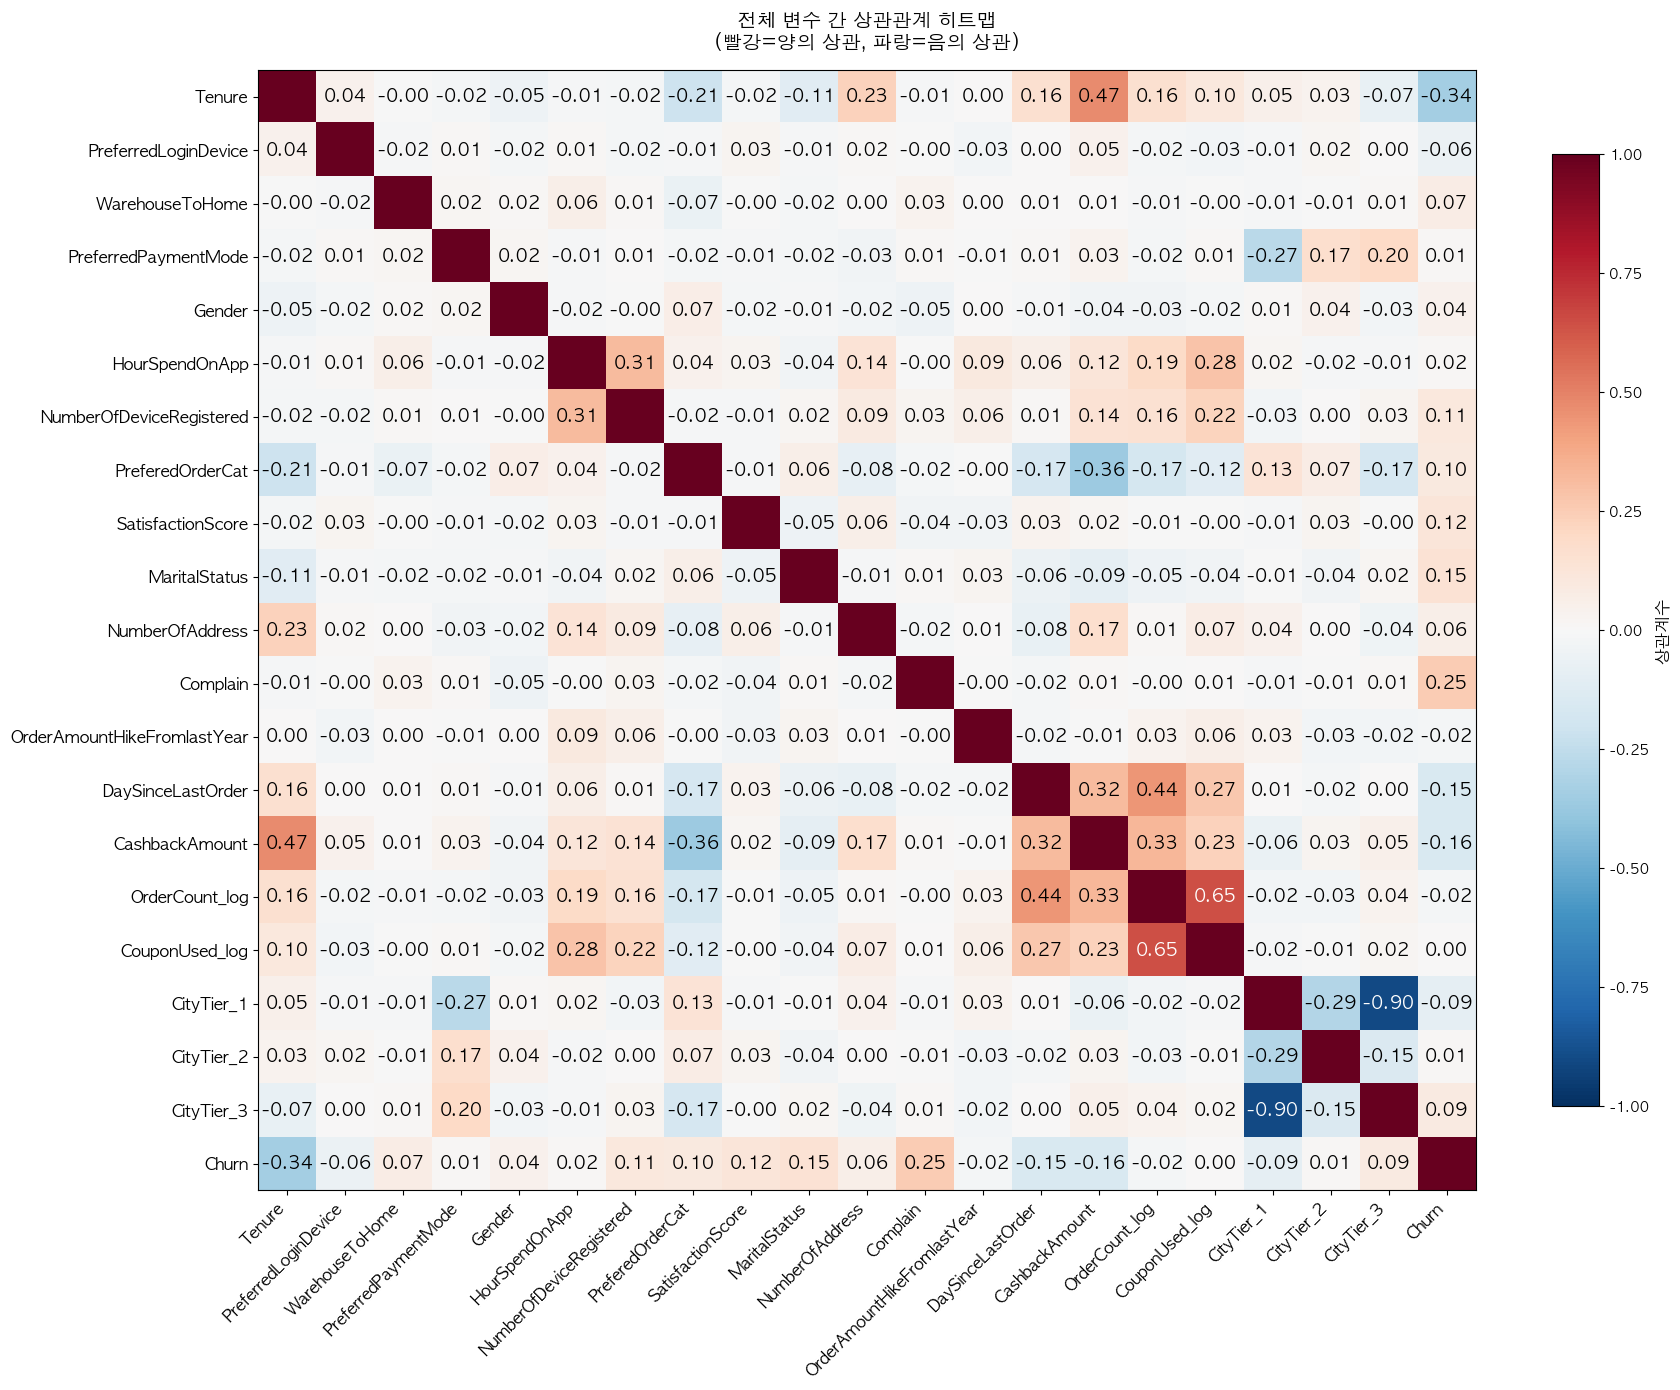

In [29]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 1 — 상관관계 히트맵】 Feature X Feature + Feature X Churn 상관관계
# ════════════════════════════════════════════════════════════════════

train_analysis = X_train.copy()
train_analysis['Churn'] = y_train.values

# 분석 대상: CustomerID 제외, 전체 수치형 변수
analysis_cols = train_analysis.columns.tolist()
corr_matrix = train_analysis.corr()

# 전체 상관관계 히트맵 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 14))

# 상관계수 히트맵 그리기
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # 상삼각 mask (선택사항)
cmap = plt.cm.RdBu_r  # 빨강=양의 상관, 파랑=음의 상관

im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')

# 컬러바
cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("상관계수", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# 축 설정
ax.set_xticks(range(len(analysis_cols)))
ax.set_yticks(range(len(analysis_cols)))
ax.set_xticklabels(analysis_cols, rotation=45, ha="right", fontsize=12)
ax.set_yticklabels(analysis_cols, fontsize=12)

# 상관계수 값 텍스트 추가
for i in range(len(analysis_cols)):
    for j in range(len(analysis_cols)):
        val = corr_matrix.values[i, j]
        if i != j:  # 대각선 제외 (대각선은 항상 1)
            # 배경색에 따라 글자색 변경
            text_color = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                   fontsize=13, color=text_color, fontweight="bold")

ax.set_title("전체 변수 간 상관관계 히트맵\n(빨강=양의 상관, 파랑=음의 상관)", 
             fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

#### 2. Feature X Churn 상관관계

| 이탈 핵심 원인 (Positive Correlation) | 이탈의 강력한 방어기제 (Negative Correlation) |
| --- | --- |
| 오른쪽으로 뻗은 <font style='color: #ff2e2e'>빨간색</font> 막대. <br> 수치가 높을수록 이탈 가능성 ⬆️<br> | 왼쪽으로 뻗은 <font style='color: #3a86ff'>파란색</font> 막대. <br> 수치가 낮을수록(음수일수록) 이탈 가능성 ⬇️<br> |
| Complain (+0.254) | Tenure (-0.343) |
| MaritalStatus (+0.148) | CashbackAmount (-0.156) |
| SatisfactionScore (+0.120) | DaySinceLastOrder (-0.152) |


<mark style='background-color: LemonChiffon'>불만(Complain)을 관리하고, 가입 기간(Tenure)과 캐시백(Cashback)을 통해 고객의 충성도를 높이는 것이 이탈 방지의 핵심</mark>

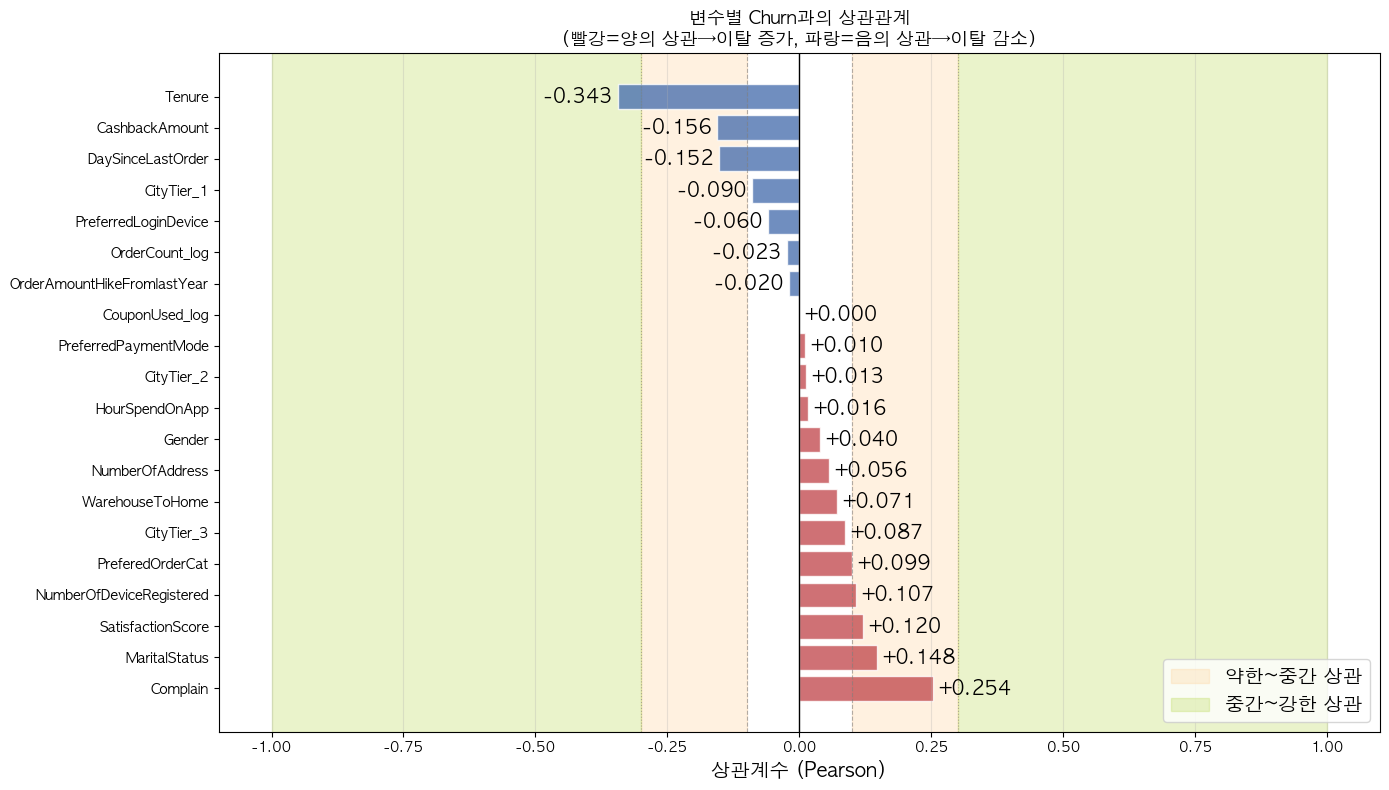


📋 Churn 상관관계 요약:
Complain                       0.254
MaritalStatus                  0.148
SatisfactionScore              0.120
NumberOfDeviceRegistered       0.107
PreferedOrderCat               0.099
CityTier_3                     0.087
WarehouseToHome                0.071
NumberOfAddress                0.056
Gender                         0.040
HourSpendOnApp                 0.016
CityTier_2                     0.013
PreferredPaymentMode           0.010
CouponUsed_log                 0.000
OrderAmountHikeFromlastYear   -0.020
OrderCount_log                -0.023
PreferredLoginDevice          -0.060
CityTier_1                    -0.090
DaySinceLastOrder             -0.152
CashbackAmount                -0.156
Tenure                        -0.343


In [30]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 2 — Feature X Churn 상관관계 Bar 차트】
# ════════════════════════════════════════════════════════════════════
train_analysis = X_train.copy()
train_analysis['Churn'] = y_train.values
corr_matrix = train_analysis.corr()

# Churn과의 상관계수 추출 (기존 코드와 동일)
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))

# 참조 영역 배경
ax.axvspan(0.1, 0.3, alpha=0.3, color="#ffd199", label="약한~중간 상관")
ax.axvspan(-0.3, -0.1, alpha=0.3, color="#ffd199")
ax.axvspan(0.3, 1.0, alpha=0.3, color="#bada55", label="중간~강한 상관")
ax.axvspan(-1.0, -0.3, alpha=0.3, color="#bada55")

# 색상 설정: 양의 상관(빨강) vs 음의 상관(파랑)
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in churn_corr.values]

bars = ax.barh(churn_corr.index, churn_corr.values, color=colors, alpha=0.8, edgecolor="white")

# 상관계수 값 텍스트
for bar, val in zip(bars, churn_corr.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=14, fontweight="bold")

# 기준선
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(-0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.axvline(-0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)

ax.set_xlabel("상관계수 (Pearson)", fontsize=14)
ax.set_title("변수별 Churn과의 상관관계\n(빨강=양의 상관→이탈 증가, 파랑=음의 상관→이탈 감소)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=14)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 Churn 상관관계 요약:")
print(churn_corr.sort_values(ascending=False).round(3).to_string())

### 2. 변수 그룹핑 분석 (상관관계 기반)

**분석 목적:**
- <mark style='background-color: LemonChiffon'>데이터의 단순화</mark> : 18개의 변수를 일일이 대응하는 대신 컬럼별 상관관계 기반으로 그룹을 묶어 비즈니스 전략을 세우기 쉬운 지표로 변환
- <mark style='background-color: LemonChiffon'>복합적 요인 파악</mark> : 고객은 단 하나의 이유로 떠나지 않기에 여러 요인이 결합되었을 때, 발생하는 시너지 효과 확인
- <mark style='background-color: LemonChiffon'>전략적 우선순위 설정</mark> : 어떤 서비스 영역(프로모션, 품질, 프로필 등)을 가장 먼저 개선해야 이탈을 효율적으로 막을 수 있는지 결정

각 그룹의 변수들을 표준화 후 평균 → 그룹 합성 점수(1컬럼)로 만들어
각 그룹이 Churn과 얼마나 상관되는지 비교

**그룹핑 기준 및 결과 해석**

| **그룹명** | **포함된 컬럼명** | **논리적 연결고리** | **상관계수** | **해석** |
| --- | --- | --- | --- | --- |
| GRP\_LifestageRisk | `Complain`, `MaritalStatus` | 삶의 큰 환경 변화가 생길 때 기존 서비스를 해지할 위험이 가장 높음 | +0.282 | 이탈에 가장 치명적인 위험 요인 |
| GRP\_LogDistress | `WarehouseToHome`, `Complain` | 이용 중 겪는 불편함과 스트레스가 이탈로 직결됨 | +0.226 | 서비스 품질 불만족에 따른 강력한 이탈 신호 |
| GRP\_PromoGap | `Complain`, `SatisfactionScore`, `CouponUsed_log` | 할인이 끝나거나 더 저렴한 경쟁사로 옮길 유인이 생길 때 이탈함 | +0.218 | 가격 민감도가 높은 이탈 위험군 |
| GRP\_LivStability | `CityTier_2`,`CityTier_3`, `NumberOfAddress` | 생활 패턴이 고착화된 상태에서 발생하는 미세한 이탈 경향 | +0.096 | 이탈과 약한 상관관계를 보임 |
| GRP\_TenureFatigue | `Tenure`, `Complain` | 오래 사용한 고객일수록 안정감이 생겨 이탈을 덜 고민함 | \-0.063 | 미미하지만 이탈을 방어하는 요소 |
| GRP\_PfDep |  `DaySinceLastOrder`, `OrderCount_log`, `CouponUsed_log`| 서비스를 생활 필수 요소로 활용하고 있어 이탈 가능성이 낮음 | \-0.073 | 완만한 수준의 이탈 억제 효과 |
| GRP\_LoyLockIn | `Tenure`, `SatisfactionScore`, `CashbackAmount`| 강력한 결합 상품이나 계약으로 묶여 있어 이탈이 가장 어려움 | \-0.190 | 이탈 방지 효과가 가장 강력한 핵심 방어군 |


#### 1. 그룹별 상관관계 히트맵 : 그룹핑된 변수들의 내부 상관관계

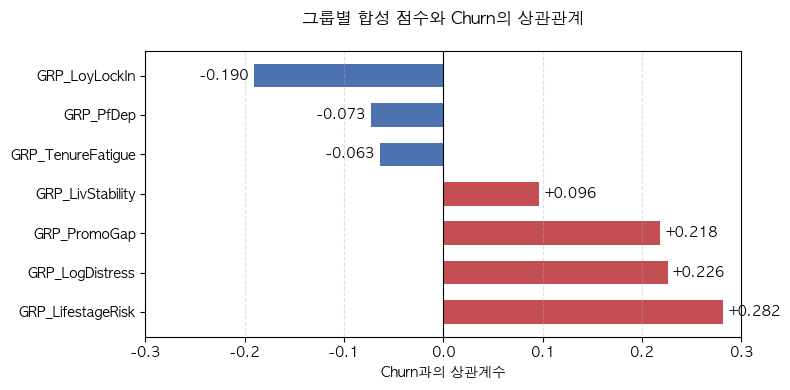

현재 X_train 컬럼 수: 55개


In [36]:
# ════════════════════════════════════════════════════════════════════
# 그룹 합성 점수 → Churn 상관관계
# ════════════════════════════════════════════════════════════════════

def create_group_features(df_input, scaler_dict=None, fit=False):
    df_temp = df_input.copy()
    
    if 'MaritalStatus' in df_temp.columns and df_temp['MaritalStatus'].dtype == object:
        df_temp['MaritalStatus'] = df_temp['MaritalStatus'].map({'Single': 0, 'Married': 1, 'Divorced': 2})
    
    groups = {
        'GRP_LifestageRisk': ['MaritalStatus', 'Complain'],
        'GRP_PromoGap':      ['CouponUsed_log', 'SatisfactionScore', 'Complain'],
        'GRP_TenureFatigue': ['Tenure', 'Complain'],
        'GRP_LogDistress':   ['WarehouseToHome', 'Complain'],
        'GRP_LoyLockIn':     ['Tenure', 'CashbackAmount', 'SatisfactionScore'],
        'GRP_LivStability':  ['CityTier_2', 'CityTier_3', 'NumberOfAddress'],
        'GRP_PfDep':         ['DaySinceLastOrder', 'OrderCount_log', 'CouponUsed_log'],
    }
    
    if scaler_dict is None:
        scaler_dict = {}
    
    df_res = pd.DataFrame(index=df_input.index)
    for grp_name, cols in groups.items():
        if fit:
            scaler = StandardScaler()
            scaled = scaler.fit_transform(df_temp[cols])
            scaler_dict[grp_name] = scaler
        else:
            scaled = scaler_dict[grp_name].transform(df_temp[cols])
        df_res[grp_name] = scaled.mean(axis=1)
    
    return df_res, scaler_dict

# 사용
# ── Step 1: train으로 fit하고 상관관계 시각화 ──
train_groups, scalers = create_group_features(X_train, fit=True)

temp_for_corr = pd.concat([train_groups, y_train], axis=1)
group_corr = temp_for_corr.corr()['Churn'].drop('Churn').sort_values(ascending=False)

# 시각화
plt.figure(figsize=(8, 4))
colors = ["#C44E52" if x > 0 else "#4C72B0" for x in group_corr.values]
bars = plt.barh(group_corr.index, group_corr.values, color=colors, height=0.6)
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 0.005 if width >= 0 else width - 0.005
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2,
             f'{width:+.3f}', va='center',
             ha='left' if width >= 0 else 'right',
             fontsize=10, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlim(-0.3, 0.3)  # 이 줄 추가
plt.title('그룹별 합성 점수와 Churn의 상관관계', fontsize=12, pad=20)
plt.xlabel('Churn과의 상관계수')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Step 2: 실제 데이터셋에 그룹 변수 합치기 (scalers 재사용) ──
val_groups,  _ = create_group_features(X_val,  scaler_dict=scalers)
test_groups, _ = create_group_features(X_test, scaler_dict=scalers)

X_train = pd.concat([X_train, train_groups], axis=1)
X_val   = pd.concat([X_val,   val_groups],   axis=1)
X_test  = pd.concat([X_test,  test_groups],  axis=1)

print(f"현재 X_train 컬럼 수: {len(X_train.columns)}개")

#### 2. Churn 상관관계 바 차트 : Churn과의 상관관계 정렬

In [37]:
# ════════════════════════════════════════════════════════════════════
# 【Fig 2 — Churn 상관관계 바 차트】 Churn과의 상관관계 정렬
# ════════════════════════════════════════════════════════════════════

# Churn과의 상관계수 추출
churn_corr = corr_matrix["Churn"].drop("Churn").sort_values(ascending=False)

def add_binned_features_from_config(df_input, config):
    df_res = df_input.copy()
    
    for col, settings in config.items():
        grp_col_name = f"{col}_bin"
        
        # 1. 구간화 적용 (pd.cut 사용)
        binned_series = pd.cut(
            df_res[col], 
            bins=settings['bins'], 
            labels=settings['labels'], 
            include_lowest=True
        )
        
        # 2. 모델 학습을 위해 카테고리 형식을 숫자로 변환 (0, 1, 2, 3...)
        # 이렇게 하면 '0-3개월'은 0, '4-6개월'은 1이 되어 모델이 순서 의미를 파악합니다.
        df_res[grp_col_name] = binned_series.cat.codes
        
    return df_res

# 실제 데이터셋(X_train, X_val, X_test)에 적용
X_train = add_binned_features_from_config(X_train, bin_configs)
X_val = add_binned_features_from_config(X_val, bin_configs)
X_test = add_binned_features_from_config(X_test, bin_configs)

print("구간 변수가 추가된 후 컬럼 예시:", X_train.filter(like='_bin').columns.tolist())


fig, ax = plt.subplots(figsize=(14, 8))

# 참조 영역 배경
ax.axvspan(0.1, 0.3, alpha=0.3, color="#ffd199", label="약한~중간 상관")
ax.axvspan(-0.3, -0.1, alpha=0.3, color="#ffd199")
ax.axvspan(0.3, 1.0, alpha=0.3, color="#bada55", label="중간~강한 상관")
ax.axvspan(-1.0, -0.3, alpha=0.3, color="#bada55")

# 색상 설정: 양의 상관(빨강) vs 음의 상관(파랑)
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in churn_corr.values]

bars = ax.barh(churn_corr.index, churn_corr.values, color=colors, alpha=0.8, edgecolor="white")

# 상관계수 값 텍스트
for bar, val in zip(bars, churn_corr.values):
    offset = 0.01 if val >= 0 else -0.01
    ha = "left" if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=14, fontweight="bold")

# 기준선
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(-0.1, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.axvline(-0.3, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)

ax.set_xlabel("상관계수 (Pearson)", fontsize=14)
ax.set_title("변수별 Churn과의 상관관계\n(빨강=양의 상관→이탈 증가, 파랑=음의 상관→이탈 감소)",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=14)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📋 Churn 상관관계 요약:")
print(churn_corr.sort_values(ascending=False).round(3).to_string())

NameError: name 'bin_configs' is not defined

### 3. 왜도가 큰 변수 구간별 Churn 관계 분석

**분석 목적:**</br>
한쪽으로 쏠려있는 데이터(왜도 skewness > 0.5)를 구간(bin)별로 나누어 각 구간의 이탈률(Churn Rate)을 분석</br>
이를 통해 특정 구간에서 이탈이 집중되는 패턴을 파악하고, 비즈니스 인사이트 도출

**왜도가 큰 변수 목록 (기존 분석에서 확인된 왜도 > 0.5)**

| 변수명 | 왜도 | 쏠린 방향 | 분석 방법 |
|---|---|---|---|
| **CouponUsed** | 2.17 → 로그변환 후 -1.51 | 오른쪽 꼬리(극단값) | 로그 스케일 구간별 분석 |
| **OrderCount** | 2.23 → 로그변환 후 -0.97 | 오른쪽 꼬리(극단값) | 로그 스케일 구간별 분석 |
| **WarehouseToHome** | 1.83 | 오른쪽 꼬리(거리가 먼 고객) | 원본 거리 구간별 분석 |
| **Tenure** | 0.89 | 약간 오른쪽 꼬리(단기 고객 밀집) | 원본 구간별 분석 |

**분석 결과** : 
| 변수명 | 패턴 | 인사이트 |
|---|---|---|
| **CouponUsed** | 쿠폰 사용이 6-9회인 구간 : 이탈률 <mark style='background-color: LemonChiffon'>33.33%</mark>로 전체 평균보다 2배 가까이 급증 | - 쿠폰을 많이 준다고 무조건 이탈을 막을 수 있는 것은 아님 <br> - 혜택을 챙기기 위해 활동하다가 만족하지 못해 떠나는 '체리피커' 성향이 있거나, 쿠폰 유효기간이 끝나는 시점에 대거 이탈할 가능성이 높음 |
| **OrderCount** | - 초신규(1회), 성장기(4-6회) 고객의 이탈률이 높음 | - 첫 구매 후 재구매로 넘어가는 단계가 고비 <br> - 4-6회차 고객들에게 새로운 자극(리텐션 전략)이 부족할 수 있음|
| **WarehouseToHome** | <mark style='background-color: LemonChiffon'>10km 미만 거리</mark>에 사는 고객들의 이탈률 가장 높음 | - 보통 거리가 멀면 배송 지연 때문에 이탈할 거라 생각하나, 가까운 거리 고객들은 배송 속도에 높은 기대감, 근처 오프라인 매장/해당 지역에 강력한 경쟁 업체가 있을 가능성 고려 (10km 이상 데이터가 0%인 것은 표본 수가 적어서일 수도 있음을 고려)|
| **Tenure** | 0-3개월차 초신규 고객 이탈률이 가장 높음 | - 가장 중요한 변수가 될 확률 높음 <br> - 고객이 가입 후 초기 3개월만 잘 버티게 하면 장기 고객으로 전환될 확률이 매우 높음 |

In [ ]:
# 왜도가 큰 변수별 구간 설정 및 Churn Rate 분석

# 분석 대상 변수와 구간 설정
bin_configs = {
    "CouponUsed_log": {
        "bins": [0, 1, 3, 6, 10, 17],
        "labels": ["0(미사용)", "1-2(낮음)", "3-5(중간)", "6-9(높음)", "10+(단골)"],
        "title": "쿠폰 사용 횟수별 이탈률"
    },
    "OrderCount_log": {
        "bins": [1, 2, 4, 7, 10, 17],
        "labels": ["1(초기)", "2-3(낮음)", "4-6(중간)", "7-9(높음)", "10+(단골)"],
        "title": "주문 횟수별 이탈률"
    },
    "WarehouseToHome": {
        "bins": [0, 10, 20, 30, 50, 130],
        "labels": ["~10km(가깝)", "10-20km", "20-30km", "30-50km", "50km+(먼)"],
        "title": "물류센터 거리별 이탈률"
    },
    "Tenure": {
        "bins": [0, 3, 6, 12, 24, 62],
        "labels": ["0-3개월(입문)", "4-6개월(초기)", "7-12개월(성장)", "13-24개월(안정기)", "25개월+(장기)"],
        "title": "이용 기간별 이탈률"
    }
}

# 구간별 Churn Rate 분석 및 시각화

analysis_df = X_train.copy()
analysis_df['Churn'] = y_train.values


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (col, config) in enumerate(bin_configs.items()):
    # 구간화 적용 (pd.cut)
    grp_col = f"{col}_grp"
    analysis_df[grp_col] = pd.cut(
        analysis_df[col], 
        bins=config['bins'], 
        labels=config['labels'], 
        include_lowest=True
    )
    
    # 구간별 이탈률(평균) 계산
    group_data = analysis_df.groupby(grp_col)['Churn'].mean().reset_index()
    
    # 막대 그래프 그리기
    sns.barplot(
        data=group_data, 
        x=grp_col, 
        y='Churn', 
        ax=axes[i], 
        palette='viridis',
        edgecolor='black'
    )
    
    # 그래프 디테일 설정
    axes[i].set_title(config['title'], fontsize=15, fontweight='bold', pad=10)
    axes[i].set_xlabel("구간", fontsize=12)
    axes[i].set_ylabel("이탈률", fontsize=12)
    axes[i].set_ylim(0, analysis_df['Churn'].mean() * 2.5) # 비교를 위해 y축 범위 조정
    
    # 막대 위에 수치 표시
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2%}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         fontsize=11, fontweight='bold', 
                         xytext=(0, 9), 
                         textcoords='offset points')

    # 전체 평균 이탈률 선 표시 (기준점)
    axes[i].axhline(analysis_df['Churn'].mean(), color='red', linestyle='--', label='전체 평균')
    axes[i].legend()

plt.tight_layout()
plt.show()

# 다중공선성(Multicollinearity) 검토 및 개선된 그룹핑

**문제점:** 변수가 여러 그룹에 중복 포함되어 있어 다중공선성 문제가 있을 수 있음

**해결 방법:** VIF(Variance Inflation Factor)를 계산하여 높은 VIF(>5) 피처 확인 후 그룹핑 개선

In [ ]:
# ─────────────────────────────────────────────
# VIF (Variance Inflation Factor) 계산 — 다중공선성 검토
# ─────────────────────────────────────────────
# 수치형 피처만 추출 (CustomerID, Churn, bin 컬럼 제외)
feature_cols = [col for col in X_train.columns 
                if col not in ["CustomerID", "Churn"] 
                and not col.endswith("_bin")]

X_vif = X_train[feature_cols].dropna()

# VIF 계산
vif_data = pd.DataFrame()
vif_data["변수"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(feature_cols))]
vif_data = vif_data.sort_values("VIF", ascending=False)

# VIF 해석 기준
def vif_interpret(vif):
    if vif < 5:
        return "✅ 양호"
    elif vif < 10:
        return "⚠️ 주의"
    else:
        return "❌ 제거"

vif_data["판단"] = vif_data["VIF"].apply(vif_interpret)

print("📋 VIF (Variance Inflation Factor) 분석 결과:")
display(vif_data.set_index("변수")
        .style.set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

print("\n💡 VIF 해석 가이드:")
print("   - VIF < 5  : 다중공선성이 낮아 양호")
print("   - 5 ≤ VIF < 10 : 중간 수준 주의")
print("   - VIF ≥ 10 : 높은 다중공선성 → 제거 또는 그룹화 권장")

In [ ]:
# 다중 공선성 해결
# CityTier_1을 제거
df_encoded = df_encoded.drop(columns=['CityTier_1'], errors='ignore')

# 그 후 다시 VIF를 계산해보면 CityTier_3의 '주의' 수치도 함께 낮아질 가능성이 큽니다.
# X_train/val/test에서도 제거
for dataset in [X_train, X_val, X_test]:
    if 'CityTier_1' in dataset.columns:
        dataset.drop(columns=['CityTier_1'], inplace=True)

In [ ]:
# 다중 공선성 해결 후, 재 확인
# 수치형 피처만 추출 (CustomerID, Churn, bin 컬럼 제외)
feature_cols = [col for col in X_train.columns 
                if col not in ["CustomerID", "Churn"] 
                and not col.endswith("_bin")]

X_vif = X_train[feature_cols].dropna()

# VIF 계산
vif_data = pd.DataFrame()
vif_data["변수"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(feature_cols))]
vif_data = vif_data.sort_values("VIF", ascending=False)

# VIF 해석 기준
def vif_interpret(vif):
    if vif < 5:
        return "✅ 양호"
    elif vif < 10:
        return "⚠️ 주의"
    else:
        return "❌ 제거"

vif_data["판단"] = vif_data["VIF"].apply(vif_interpret)

print("📋 VIF (Variance Inflation Factor) 분석 결과:")
display(vif_data.set_index("변수")
        .style.set_properties(**{"text-align": "left"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

print("\n💡 VIF 해석 가이드:")
print("   - VIF < 5  : 다중공선성이 낮아 양호")
print("   - 5 ≤ VIF < 10 : 중간 수준 주의")
print("   - VIF ≥ 10 : 높은 다중공선성 → 제거 또는 그룹화 권장")

# 데이터 불균형(Class Imbalance) 처리 분석

**현재 이탈(Churn) 분포(train set 기준):**
 - 유지(0) : 2809명 (83.16%)
 - 이탈(1) : 569명 (16.84%)
 - 합계    : 3378명

**클래스 불균형 문제**
- 모델이 다수 클래스(유지)에 치우쳐 학습될 수 있음
- 이탈 고객(소수 클래스)을 정확히 예측하지 못할 위험
- Accuracy만으로는 실제 성능을 판단할 수 없음

In [ ]:
def check_churn_dist(y_data, title):
    counts = y_data.value_counts()
    ratio = y_data.value_counts(normalize=True)
    print(f"📊 [{title}]")
    print(f" - 유지(0): {counts[0]}명 ({ratio[0]:.2%})")
    print(f" - 이탈(1): {counts[1]}명 ({ratio[1]:.2%})")
    print(f" - 합계  : {len(y_data)}명")
    print("-" * 35)

# 각각의 데이터셋에 대해 실행
check_churn_dist(y, "Original Total (전체 원본) 이탈 분포")
check_churn_dist(y_train, "Train Set (학습용) 이탈 분포")
check_churn_dist(y_val, "Validation Set (검증용) 이탈 분포")
check_churn_dist(y_test, "Test Set (테스트용) 이탈 분포")

#### 1. 데이터 불균형 처리 방법

| <br> | 1️⃣ 클래스 가중치 (scale\_pos\_weight) | 2️⃣ SMOTE 오버샘플링 | 3️⃣ SMOTE + Tomek Links (Hybrid)<br> |
| --- | --- | --- | --- |
| 전략<br> | 데이터 수는 그대로 두되, <br> 소수파(1)를 하나 맞힐 때마다 점수를 5배(4.94) 더 주는 방식<br> | 부족한 소수파(1) 데이터를 가짜로 더 만들어서 <br> 양을 똑같이 맞춥니다. (2,809행 vs 2,809행)<br> | 가짜 데이터를 만들되(SMOTE), 0과 1의 경계선에 애매하게 걸쳐 있어서 모델을 헷갈리게 하는 데이터들을 삭제해서 정리<br> |
| 비유  | 시험 문제에서 어려운 배점 높은 문제(이탈 고객)에 가산점을 팍팍 주는 것 | 소수파 학생들의 복사본(가짜 데이터)을 만들어서 교실 인원수를 5:5로 맞추는 것 | 교실 인원을 맞춘 뒤, 앞뒤가 안 맞는 이상한 녀석들을 퇴출시켜 공부 환경을 쾌적하게 만드는 것<br> |


In [ ]:
# ─────────────────────────────────────────────
# 불균형 처리 방법 비교 분석
# ─────────────────────────────────────────────

# 현재 클래스 분포 
churn_dist = y_train.value_counts()
print("📊 현재 클래스 분포 (Train Set):")
print(f"   유지(0): {churn_dist[0]:,}명 ({churn_dist[0]/len(y_train)*100:.1f}%)")
print(f"   이탈(1): {churn_dist[1]:,}명 ({churn_dist[1]/len(y_train)*100:.1f}%)")
print(f"   불균형 비율: {churn_dist[0]/churn_dist[1]:.1f}:1")

# 베이스라인: 클래스 가중치 없는 모델 
print("\n     0️⃣베이스라인 (클래스 가중치 없음)")

base_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, 
                                 random_state=42, verbose=-1)
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)
y_proba_base = base_model.predict_proba(X_test)[:, 1]

base_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1": f1_score(y_test, y_pred_base),
    "AUC": roc_auc_score(y_test, y_proba_base)
}

for k, v in base_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

# 방법 1: 클래스 가중치 (scale_pos_weight)
print("\n 방법1️⃣ 클래스 가중치 (scale_pos_weight)")


scale_weight = churn_dist[0] / churn_dist[1]
print(f"  scale_pos_weight = {scale_weight:.2f}")

weighted_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42, verbose=-1
)
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)
y_proba_weighted = weighted_model.predict_proba(X_test)[:, 1]

weighted_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_weighted),
    "Precision": precision_score(y_test, y_pred_weighted),
    "Recall": recall_score(y_test, y_pred_weighted),
    "F1": f1_score(y_test, y_pred_weighted),
    "AUC": roc_auc_score(y_test, y_proba_weighted)
}

for k, v in weighted_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

# 방법 2: SMOTE 오버샘플링
print("\n 방법2️⃣ SMOTE 오버샘플링")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"  SMOTE 전: {len(X_train):,}행 | SMOTE 후: {len(X_train_smote):,}행")
print(f"  SMOTE 후 클래스 분포: 0={sum(y_train_smote==0):,}, 1={sum(y_train_smote==1):,}")

smote_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                  random_state=42, verbose=-1)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)
y_proba_smote = smote_model.predict_proba(X_test)[:, 1]

smote_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "Precision": precision_score(y_test, y_pred_smote),
    "Recall": recall_score(y_test, y_pred_smote),
    "F1": f1_score(y_test, y_pred_smote),
    "AUC": roc_auc_score(y_test, y_proba_smote)
}

for k, v in smote_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

# 방법 3: SMOTE + Tomek Links (Hybrid)
print("\n 방법3️⃣ SMOTE + Tomek Links (Hybrid)")

hybrid = SMOTETomek(random_state=42)
X_train_hybrid, y_train_hybrid = hybrid.fit_resample(X_train, y_train)

print(f"  Hybrid 전: {len(X_train):,}행 | Hybrid 후: {len(X_train_hybrid):,}행")
print(f"  Hybrid 후 클래스 분포: 0={sum(y_train_hybrid==0):,}, 1={sum(y_train_hybrid==1):,}")

hybrid_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                  random_state=42, verbose=-1)
hybrid_model.fit(X_train_hybrid, y_train_hybrid)
y_pred_hybrid = hybrid_model.predict(X_test)
y_proba_hybrid = hybrid_model.predict_proba(X_test)[:, 1]

hybrid_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_hybrid),
    "Precision": precision_score(y_test, y_pred_hybrid),
    "Recall": recall_score(y_test, y_pred_hybrid),
    "F1": f1_score(y_test, y_pred_hybrid),
    "AUC": roc_auc_score(y_test, y_proba_hybrid)
}

for k, v in hybrid_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

#### 2. 불균형 처리 방법 비교 시각화

In [ ]:
# ─────────────────────────────────────────────
# 불균형 처리 방법 비교 시각화
# ─────────────────────────────────────────────

# 결과 비교 테이블
comparison_df = pd.DataFrame({
    "베이스라인\n(가중치 없음)": base_metrics,
    "방법1\n(클래스 가중치)": weighted_metrics,
    "방법2\n(SMOTE)": smote_metrics,
    "방법3\n(SMOTE+Tomek)": hybrid_metrics
}).T

print("📋 불균형 처리 방법별 성능 비교:")
display(comparison_df.round(4).style.set_properties(**{'text-align': 'left'})
                          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

# ── Fig: 성능 비교 바 차트 ─────────────────────────────────────
metrics_list = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
methods = ["Base", "Weighted", "SMOTE", "Hybrid"]
results = {
    "Base": list(base_metrics.values()),
    "Weighted": list(weighted_metrics.values()),
    "SMOTE": list(smote_metrics.values()),
    "Hybrid": list(hybrid_metrics.values())
}

x = np.arange(len(metrics_list))
width = 0.2
colors = ["gray", "#C44E52", "#4C72B0", "#E07B00"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (method, vals) in enumerate(results.items()):
    bars = ax.bar(x + i*width - 1.5*width, vals, width, label=method, color=colors[i], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("불균형 처리 방법별 성능 비교", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)

# 값 표시
for i, (method, vals) in enumerate(results.items()):
    for j, val in enumerate(vals):
        ax.text(j + i*width - 1.5*width, val + 0.02, f"{val:.2f}", 
                ha="center", va="bottom", fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

### 3. 불균형 처리 결정 -> 클래스 가중치

- **분석 결과** : 데이터의 불균형을 해결하려는 이유는 단순히 숫자를 높이는 것이 아닌, 이탈자를 얼마나 놓치지 않고 잘 잡아내느냐를 보기 위함
- 예측 모델에서는 재현율(Recall)이 가장 중요
- 재현율이 높아야 나갈 사람을 미리 찾아 고객 이탈을 막을 수 있기 때문
- 재현율이 가장 높은 클래스 가중치로 불균형 처리
<br>

|     | Accuracy(정확도) | Precision(정밀도) | Recall(재현율) | F1  | AUC |
| --- | --- | --- | --- | --- | --- |
| 베이스라인 (가중치 없음) | 0.963600 | 0.906600 | 0.873000 | 0.889500 | 0.974600 |
| 방법1 (클래스 가중치) | 0.946700 | 0.800000 | 0.910100 | 0.851500 | 0.974200 |
| 방법2 (SMOTE) | 0.944900 | 0.829000 | 0.846600 | 0.837700 | 0.972300 |
| 방법3 (SMOTE+Tomek) | 0.944900 | 0.829000 | 0.846600 | 0.837700 | 0.972300 |

# 모델 학습용 데이터 fit/transform

In [ ]:
scaler = StandardScaler()
scale_cols = X_train.select_dtypes(include=['number']).columns.tolist()

# 학습 데이터로 fit 및 변환
X_train_scaled = X_train.copy()
X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])

# 검증/테스트 데이터는 transform만
X_val_scaled = X_val.copy()
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])

X_test_scaled = X_test.copy()
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)